In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

### Questão 1
**Contexto:** fs = 20000 Hz. Filtros baseados em blocos de 2ª ordem.
Investigação dos efeitos do parâmetro $r$ (raio dos polos) na estabilidade e seletividade.

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000
def plot_frequency_variation(filters, title):

    plt.figure(figsize=(10,5))

    for item in filters:

        b = item["b"]
        a = item["a"]
        r = item["r"]

        w, h = signal.freqz(b, a, fs=fs)

        magnitude = 20 * np.log10(
            np.abs(h) + 1e-10
        )

        plt.plot(
            w,
            magnitude,
            label=f'r = {r}'
        )

    plt.title(f'Resposta em Frequência - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-50, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

In [42]:
def plot_pz(b, a, title=""):

    z, p, k = signal.tf2zpk(b, a)

    theta = np.linspace(0, 2*np.pi, 300)

    plt.figure(figsize=(6,6))

    # círculo unitário
    plt.plot(
        np.cos(theta),
        np.sin(theta),
        'k--',
        alpha=0.5
    )

    # zeros
    plt.scatter(
        np.real(z),
        np.imag(z),
        marker='o',
        facecolors='none',
        edgecolors='blue',
        s=100,
        label='Zeros'
    )

    # polos
    plt.scatter(
        np.real(p),
        np.imag(p),
        marker='x',
        color='red',
        s=100,
        label='Polos'
    )

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.title(title)

    plt.xlabel('Parte Real')
    plt.ylabel('Parte Imaginária')

    plt.axis('equal')

    plt.grid(True)
    plt.legend()

    plt.show()

#### 1(a) Passa-baixas com fc = 1000 Hz

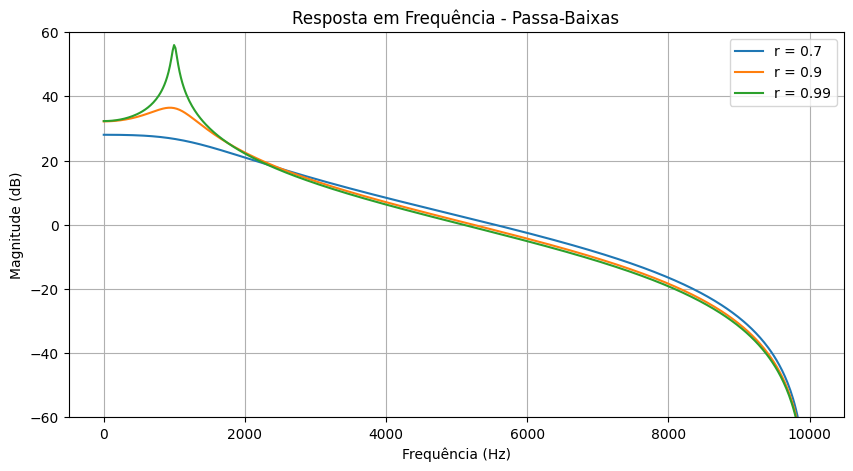

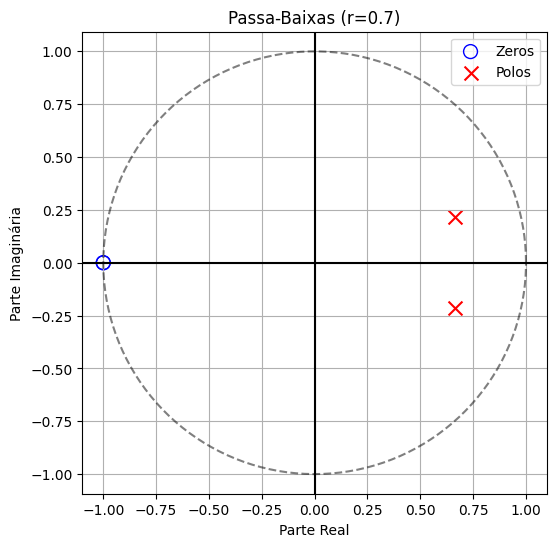

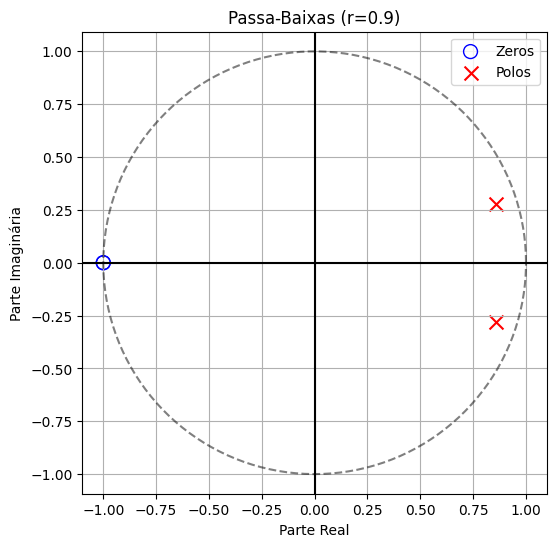

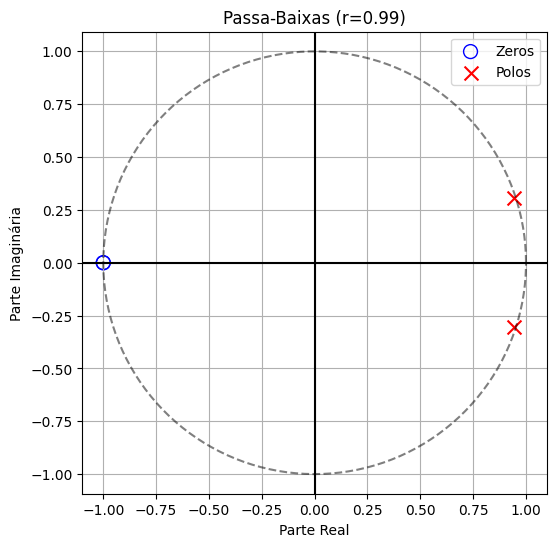

In [48]:
fc = 1000

theta = 2 * np.pi * fc / fs

filters_lp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador dos slides
    b = [1, 2, 1]

    # Denominador
    a = [1, m1, m2]

    filters_lp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_lp,
    "Passa-Baixas"
)

for item in filters_lp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Baixas (r={item["r"]})'
    )

**Comentários sobre os resultados (1a):**
- **Seletividade:** Conforme $r$ se aproxima de 1, o pico de ressonância na frequência de corte torna-se muito mais estreito e acentuado, aumentando a seletividade do filtro.
- **Estabilidade:** O sistema é estável para todos os valores testados, pois os polos estão dentro do círculo unitário ($r < 1$). No entanto, para $r=0.99$, o sistema está próximo da margem de instabilidade.
- **Largura de Banda:** A largura de banda diminui drasticamente com o aumento de $r$, estreitando a transição da banda de passagem.

#### 1(b) Passa-altas com fc = 2000 Hz

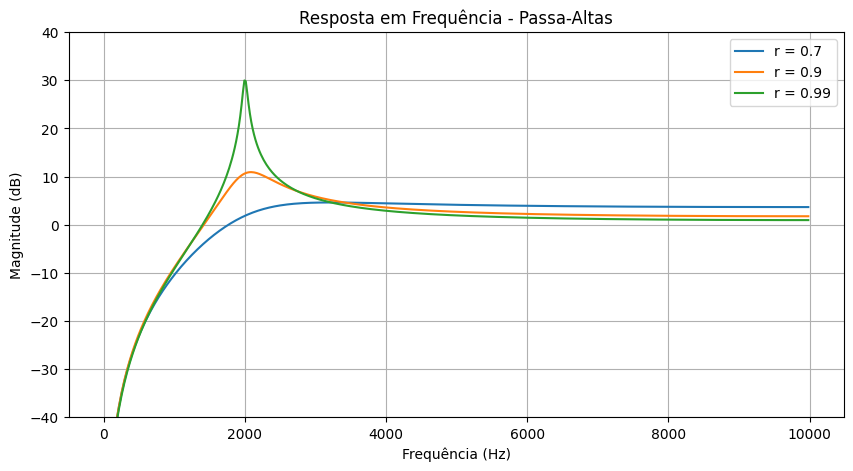

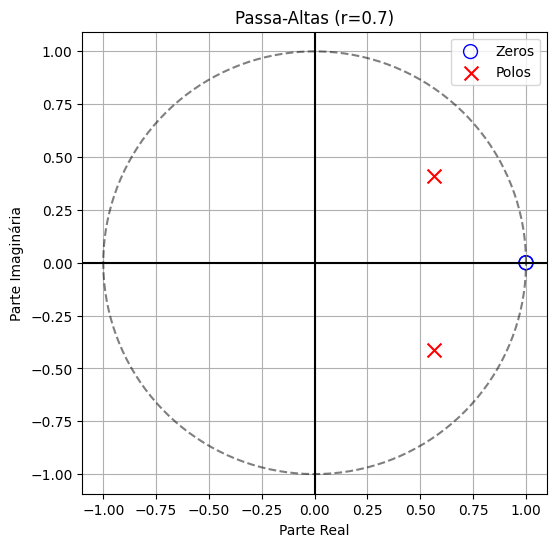

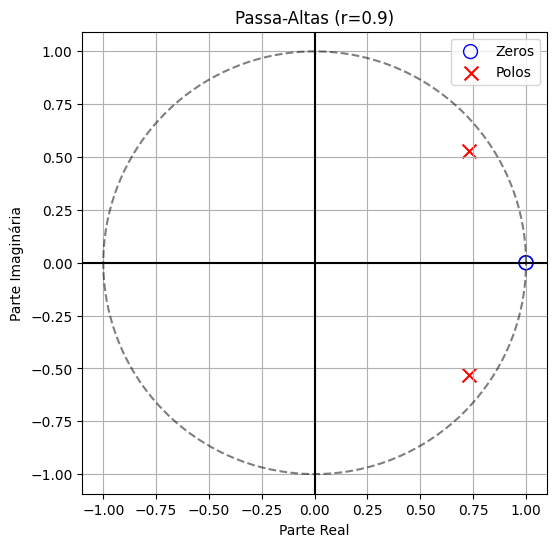

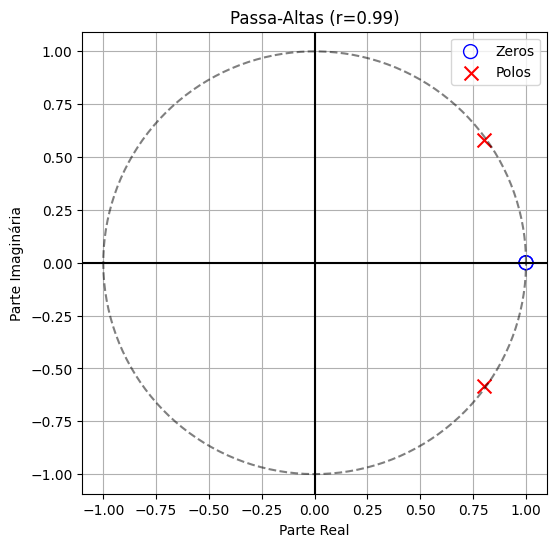

In [51]:
fc = 2000

theta = 2 * np.pi * fc / fs

filters_hp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    b = [1, -2, 1]

    a = [1, m1, m2]

    filters_hp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_hp,
    "Passa-Altas"
)

for item in filters_hp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Altas (r={item["r"]})'
    )

**Comentários sobre os resultados (1b):**
- **Seletividade:** O filtro apresenta uma rejeição maior de frequências abaixo de 2000 Hz conforme $r$ aumenta.
- **Estabilidade:** Mantém-se estável, com polos migrando para a borda do círculo unitário à medida que $r \to 1$.
- **Largura de Banda:** O aumento de $r$ reduz a região de transição, tornando o filtro mais abrupto após a frequência de corte.

#### 1(c) Passa-faixas com fc = 7000 Hz

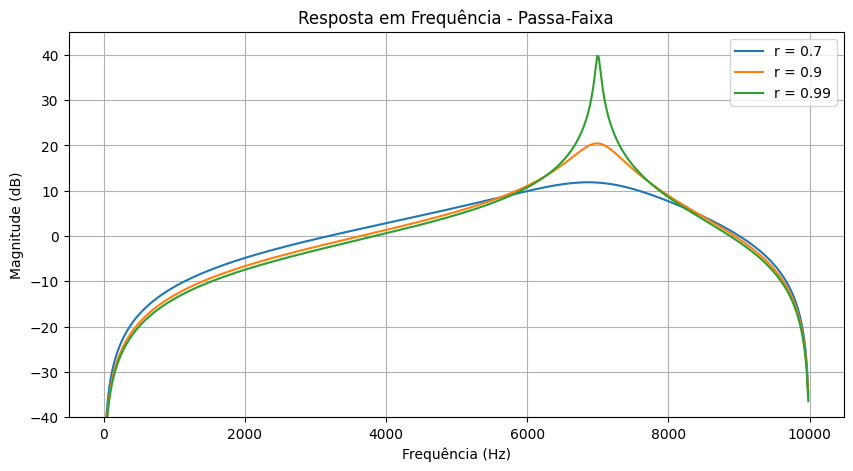

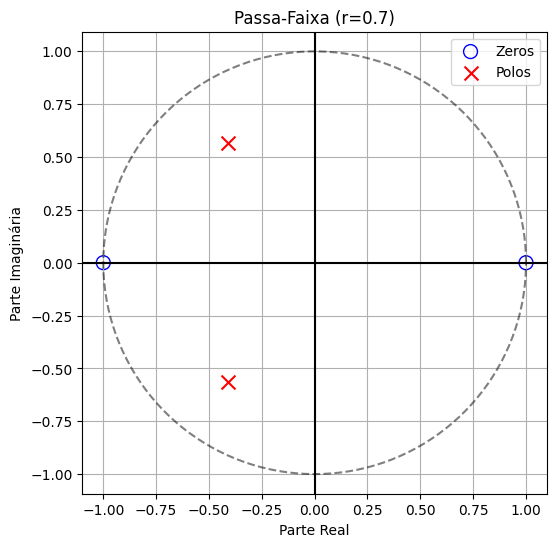

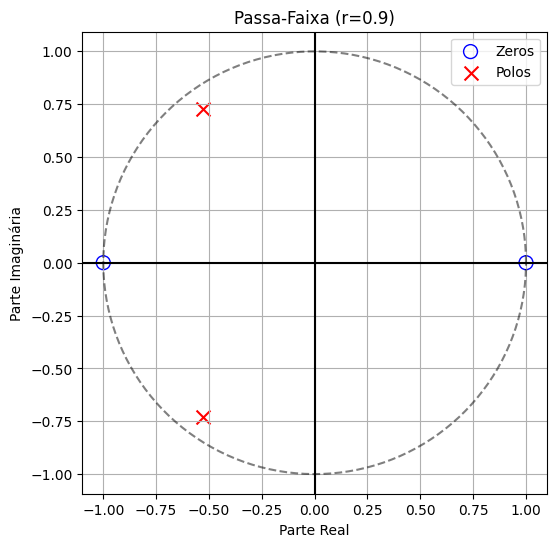

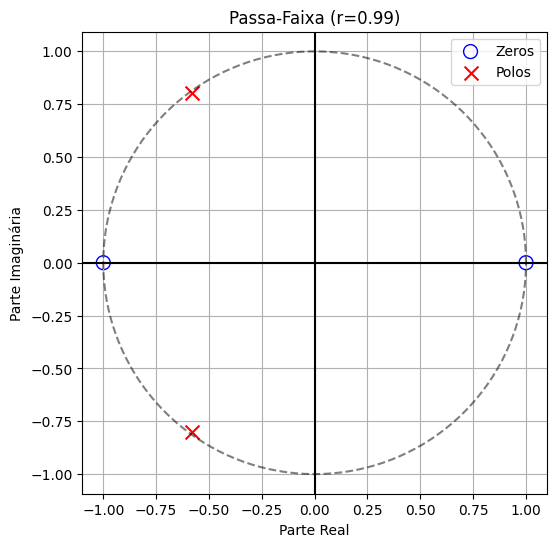

In [54]:
fc = 7000

theta = 2 * np.pi * fc / fs

filters_bp = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador correto dos slides
    b = [1, 0, -1]

    a = [1, m1, m2]

    filters_bp.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_bp,
    "Passa-Faixa"
)

for item in filters_bp:

    plot_pz(
        item["b"],
        item["a"],
        f'Passa-Faixa (r={item["r"]})'
    )

**Comentários sobre os resultados (1c):**
- **Seletividade:** A largura da banda de passagem é inversamente proporcional a $r$. Com $r=0.98$, temos um filtro de banda muito estreita (Q elevado).
- **Estabilidade:** Estável. A resposta temporal seria mais longa (maior ringing) para valores altos de $r$ devido à proximidade dos polos com o círculo unitário.
- **Largura de Banda:** Definida por $\Delta f \approx \frac{fs(1-r)}{\pi}$. Nota-se visualmente o estreitamento da banda central em 7kHz.

#### 1(d) Notch (Rejeita-faixa) com fc = 3000 Hz

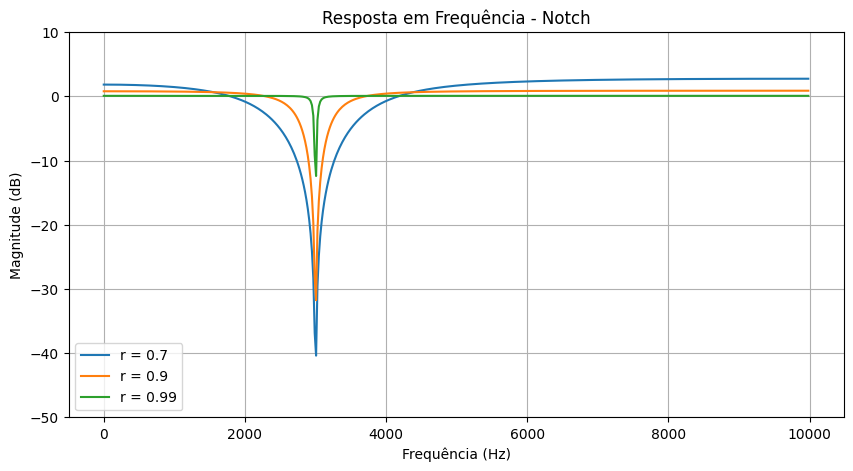

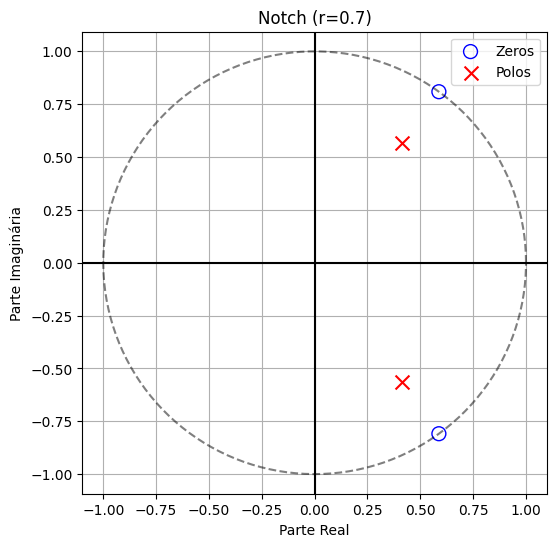

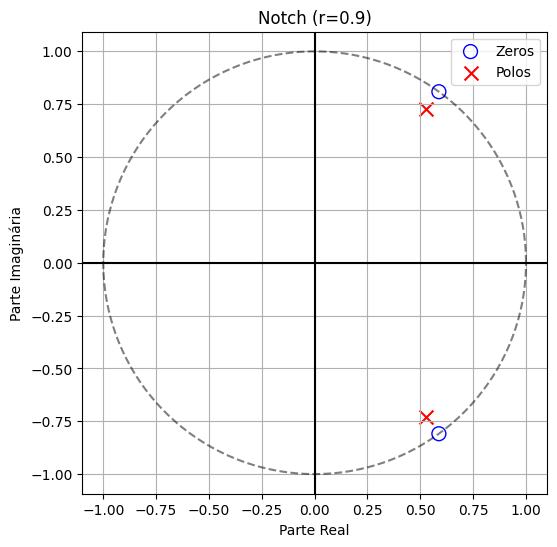

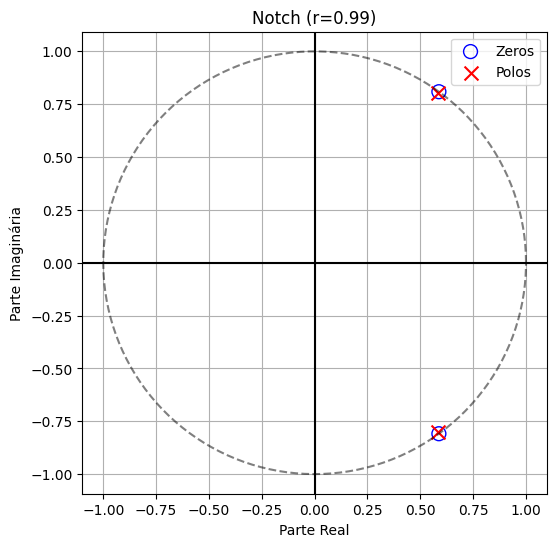

In [58]:
fc = 3000

theta = 2 * np.pi * fc / fs

filters_notch = []

for r in [0.7, 0.9, 0.99]:

    m1 = -2 * r * np.cos(theta)
    m2 = r**2

    # Numerador correto do notch
    b = [1, (m1 / np.sqrt(m2)), 1]

    a = [1, m1, m2]

    filters_notch.append({
        "b": b,
        "a": a,
        "r": r
    })

plot_frequency_variation(
    filters_notch,
    "Notch"
)

for item in filters_notch:

    plot_pz(
        item["b"],
        item["a"],
        f'Notch (r={item["r"]})'
    )

**Comentários sobre os resultados (1d):**
- **Seletividade:** O "entalhe" (notch) torna-se extremamente fino para $r=0.99$, permitindo remover uma frequência específica sem afetar as vizinhas.
- **Estabilidade:** Os zeros estão exatamente sobre o círculo unitário (rejeição infinita teórica), enquanto os polos internos garantem a estabilidade.
- **Largura de Banda:** Quanto maior o $r$, menor a largura de banda da rejeição, preservando melhor o restante do espectro do sinal.

### Questão 2
**Projeto:** Filtro Passa-Faixas (Cascata de Blocos de 2ª Ordem)
- $fs = 20000$ Hz
- $fc1 = 6000$ Hz (Corte Inferior)
- $fc2 = 8000$ Hz (Corte Superior)

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

fc1 = 6000
fc2 = 8000

# Raios dos polos
r1 = 0.15   # Passa-altas
r2 = 0.20   # Passa-baixas

In [60]:
def plot_filter_analysis(b, a, title):

    w, h = signal.freqz(
        b,
        a,
        fs=fs
    )

    zeros, poles, _ = signal.tf2zpk(
        b,
        a
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # ==================================
    # Resposta em frequência
    # ==================================

    ax1.plot(
        w,
        20*np.log10(np.abs(h)+1e-10)
    )

    ax1.set_title(
        f"Resposta em Frequência\n{title}"
    )

    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("Magnitude (dB)")

    ax1.set_ylim(-150,10)

    ax1.grid(True)

    # ==================================
    # Polos e zeros
    # ==================================

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    ax2.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    ax2.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=80,
        label='Zeros'
    )

    ax2.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=80,
        label='Polos'
    )

    ax2.axhline(0,color='black')
    ax2.axvline(0,color='black')

    ax2.set_aspect('equal')

    ax2.grid(True)

    ax2.legend()

    ax2.set_title(
        "Diagrama de Polos e Zeros"
    )

    plt.tight_layout()
    plt.show()

In [61]:
# ==================================
# PASSA-ALTAS
# ==================================

theta1 = 2*np.pi*fc1/fs

m1_hp = -2*r1*np.cos(theta1)
m2_hp = r1**2

# H(z) = (z² - 2z + 1)/(z² + m1z + m2)

b1 = np.array(
    [1, -2, 1],
    dtype=float
)

a1 = np.array(
    [1, m1_hp, m2_hp],
    dtype=float
)

In [62]:
# ==================================
# PASSA-BAIXAS
# ==================================

theta2 = 2*np.pi*fc2/fs

m1_lp = -2*r2*np.cos(theta2)
m2_lp = r2**2

# H(z) = (z² + 2z + 1)/(z² + m1z + m2)

b2 = np.array(
    [1, 2, 1],
    dtype=float
)

a2 = np.array(
    [1, m1_lp, m2_lp],
    dtype=float
)

In [63]:
# ==================================
# NORMALIZAÇÃO
# ==================================

_, h1 = signal.freqz(
    b1,
    a1,
    worN=[7000],
    fs=fs
)

b1 = b1 / np.abs(h1[0])

_, h2 = signal.freqz(
    b2,
    a2,
    worN=[7000],
    fs=fs
)

b2 = b2 / np.abs(h2[0])

In [64]:
# ==================================
# CASCATA
# ==================================

b_total = np.convolve(
    b1,
    b2
)

a_total = np.convolve(
    a1,
    a2
)

--- Filtro Passa-Faixas em Cascata ---


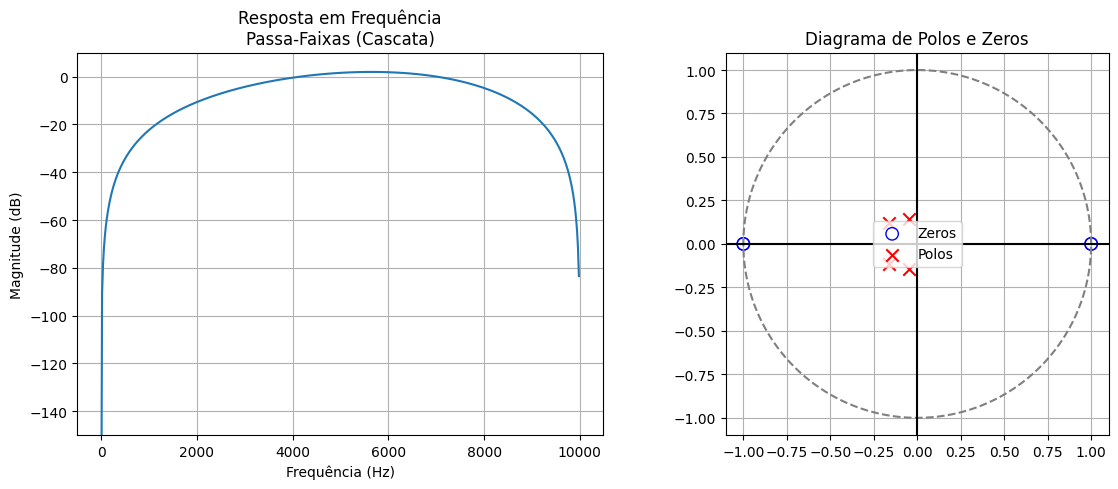

In [65]:
print(
    "--- Filtro Passa-Faixas em Cascata ---"
)

plot_filter_analysis(
    b_total,
    a_total,
    "Passa-Faixas (Cascata)"
)

In [67]:
##Função de Transferência Resultante

print("Numerador:")

print(np.round(
    b_total,
    6
))

print("\nDenominador:")

print(np.round(
    a_total,
    6
))

Numerador:
[ 0.297401  0.       -0.594801  0.        0.297401]

Denominador:
[1.00000e+00 4.16312e-01 9.25000e-02 1.09890e-02 9.00000e-04]


**Comentários sobre os resultados (Questão 2):**

- **Resposta em Frequência:** Diferente da Questão 1(c), que focava em uma única frequência central ressonante, este filtro possui uma 'banda passante' mais plana entre 6000 Hz e 8000 Hz. A inclinação nas bandas de transição é mais acentuada devido à ordem total do sistema (4ª ordem resultante da cascata de dois blocos de 2ª ordem).
- **Diagrama de Polos e Zeros:** Observamos dois pares de polos complexos conjugados, cada um correspondendo a uma das frequências de corte. Os zeros em $z=1$ (do HPF) e as características do LPF moldam a rejeição fora da faixa.
- **Comparação com a Questão 1(c):** O filtro da Questão 1(c) é um ressonador de banda muito estreita (seletivo para uma única frequência), enquanto este projeto de cascata é mais adequado para permitir a passagem de uma faixa de frequências específica, sendo mais robusto para sinais que ocupam um espectro maior.
- **Estabilidade e Largura de Banda:** O sistema é estável ($r=0.9$). A largura de banda é claramente definida pela diferença $fc2 - fc1 = 2000$ Hz, ao contrário do filtro anterior onde a largura dependia quase exclusivamente de $r$.

### Questão 3
**Projeto:** Filtro Rejeita-Faixas (Band-Stop)
- $fs = 20000$ Hz
- $fc1 = 1000$ Hz (Início da rejeição)
- $fc2 = 4000$ Hz (Fim da rejeição)

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000

fc1 = 1000
fc2 = 4000

# Raios dos polos

r1 = 0.10     # LPF
r2 = 0.20     # HPF

In [70]:
def plot_filter_analysis(b, a, title):

    w, h = signal.freqz(
        b,
        a,
        fs=fs
    )

    zeros, poles, _ = signal.tf2zpk(
        b,
        a
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12,5)
    )

    # ============================
    # Resposta em frequência
    # ============================

    ax1.plot(
        w,
        20*np.log10(np.abs(h)+1e-10)
    )

    ax1.set_title(
        f"Resposta em Frequência\n{title}"
    )

    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("Magnitude (dB)")

    ax1.set_ylim(-150,10)

    ax1.grid(True)

    # ============================
    # Polos e zeros
    # ============================

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    ax2.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    ax2.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=80,
        label='Zeros'
    )

    ax2.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=80,
        label='Polos'
    )

    ax2.axhline(0,color='black')
    ax2.axvline(0,color='black')

    ax2.grid(True)

    ax2.set_aspect('equal')

    ax2.legend()

    ax2.set_title(
        "Diagrama de Polos e Zeros"
    )

    plt.tight_layout()
    plt.show()

In [71]:
# =====================================
# PASSA-BAIXAS
# =====================================

theta1 = 2*np.pi*fc1/fs

m1_lp = -2*r1*np.cos(theta1)
m2_lp = r1**2

# H(z) = (z² + 2z + 1)/(z² + m1 z + m2)

b1 = np.array(
    [1, 2, 1],
    dtype=float
)

a1 = np.array(
    [1, m1_lp, m2_lp],
    dtype=float
)

In [72]:
# =====================================
# PASSA-ALTAS
# =====================================

theta2 = 2*np.pi*fc2/fs

m1_hp = -2*r2*np.cos(theta2)
m2_hp = r2**2

# H(z) = (z² - 2z + 1)/(z² + m1 z + m2)

b2 = np.array(
    [1, -2, 1],
    dtype=float
)

a2 = np.array(
    [1, m1_hp, m2_hp],
    dtype=float
)

In [73]:
# =====================================
# NORMALIZAÇÃO LPF
# =====================================

_, h1 = signal.freqz(
    b1,
    a1,
    worN=[100],
    fs=fs
)

b1 = b1 / np.abs(h1[0])

# =====================================
# NORMALIZAÇÃO HPF
# =====================================

_, h2 = signal.freqz(
    b2,
    a2,
    worN=[fs/2 - 100],
    fs=fs
)

b2 = b2 / np.abs(h2[0])

In [74]:
# =====================================
# REJEITA-FAIXAS
# H(z)=HLP(z)+HHP(z)
# =====================================

b_rej = np.polyadd(

    np.convolve(
        b1,
        a2
    ),

    np.convolve(
        b2,
        a1
    )
)

a_rej = np.convolve(
    a1,
    a2
)

--- Filtro Rejeita-Faixas (Paralelo) ---


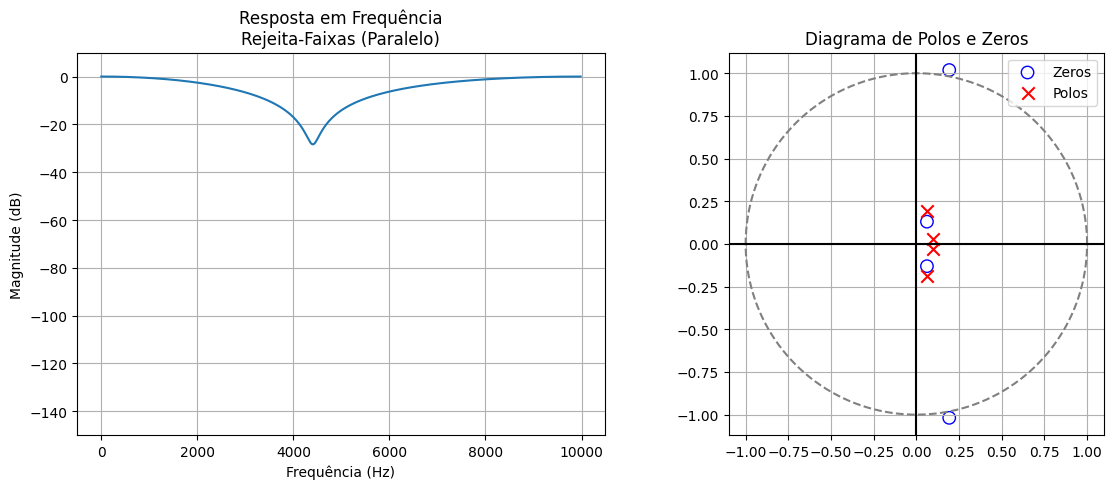

In [75]:
print(
    "--- Filtro Rejeita-Faixas (Paralelo) ---"
)

plot_filter_analysis(
    b_rej,
    a_rej,
    "Rejeita-Faixas (Paralelo)"
)

In [76]:
print("Numerador:")

print(
    np.round(
        b_rej,
        6
    )
)

print("\nDenominador:")

print(
    np.round(
        a_rej,
        6
    )
)

Numerador:
[ 0.495964 -0.252527  0.567071 -0.0701    0.01111 ]

Denominador:
[ 1.00000e+00 -3.13818e-01  7.35110e-02 -8.84500e-03  4.00000e-04]


**Comentários sobre os resultados (Questão 3):**

- **Resposta em Frequência:** O filtro apresenta uma 'vala' de atenuação significativamente mais larga do que o filtro Notch da questão 1(d). Enquanto o Notch eliminava quase exclusivamente os 3000 Hz, este filtro remove o conteúdo espectral em uma faixa de 3000 Hz de largura (de 1000 a 4000 Hz).
- **Diagrama de Polos e Zeros:** Notamos a presença de 4 polos (provenientes da combinação dos dois blocos de 2ª ordem). Os zeros não estão mais necessariamente sobre o círculo unitário em um único ponto, mas distribuídos para garantir a rejeição na faixa desejada.
- **Comparação com o Notch da Questão 1(d):**
    - O **Notch** é um filtro de rejeição de banda estreita (seletividade altíssima para uma única frequência).
    - O **Rejeita-Faixas (Questão 3)** é um filtro de banda larga, ideal para eliminar ruídos que ocupam uma faixa maior do espectro.
- **Estabilidade e Largura de Banda:** O sistema é estável ($r=0.9$). A largura de banda de rejeição é determinada pelas frequências de corte escolhidas ($fc2 - fc1 = 3000$ Hz), mostrando-se muito menos sensível a pequenas variações de $r$ do que o Notch para manter sua funcionalidade principal.

### Questão 4
**Análise de Quantização de Coeficientes**
- Filtros das Questões 2 e 3
- Bits $b \in \{2, 4, 8, 16, 32\}$
- Comparação: Quantização Direta vs. Quantização em Cascata

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def quantize_coeffs(coeffs, bits):

    coeffs = np.array(coeffs, dtype=float)

    # 32 bits ≈ sem quantização
    if bits >= 32:
        return coeffs

    max_val = np.max(np.abs(coeffs))

    if max_val == 0:
        return coeffs

    # Número de níveis
    levels = 2**(bits - 1) - 1

    # Normalização
    coeffs_norm = coeffs / max_val

    # Quantização
    coeffs_q = np.round(coeffs_norm * levels) / levels

    # Retorna escala original
    coeffs_q = coeffs_q * max_val

    return coeffs_q

In [80]:
def check_stability(a):

    poles = np.roots(a)

    stable = np.all(np.abs(poles) < 1)

    return stable, poles

In [81]:
def plot_pz(b, a, title=""):

    zeros = np.roots(b)
    poles = np.roots(a)

    theta = np.linspace(0, 2*np.pi, 500)

    plt.figure(figsize=(6,6))

    # Círculo unitário
    plt.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    # Zeros
    plt.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='blue',
        s=100,
        label='Zeros'
    )

    # Polos
    plt.scatter(
        np.real(poles),
        np.imag(poles),
        color='red',
        marker='x',
        s=100,
        label='Polos'
    )

    plt.axhline(0, color='black')
    plt.axvline(0, color='black')

    plt.grid(True)

    plt.axis('equal')

    plt.title(title)

    plt.xlabel("Parte Real")
    plt.ylabel("Parte Imaginária")

    plt.legend()

    plt.show()

In [82]:
def compare_quantization(
    b_orig,
    a_orig,
    blocks,
    fs,
    title=""
):

    bits_list = [32, 16, 8, 4, 2]

    # =========================================
    # RESPOSTA ORIGINAL
    # =========================================

    w, h = signal.freqz(
        b_orig,
        a_orig,
        fs=fs
    )

    magnitude_original = 20 * np.log10(
        np.abs(h) + 1e-10
    )

    # =========================================
    # QUANTIZAÇÃO DIRETA
    # =========================================

    plt.figure(figsize=(12,6))

    plt.plot(
        w,
        magnitude_original,
        'k--',
        linewidth=2,
        label='Original'
    )

    print("\n===================================")
    print(f"QUANTIZAÇÃO DIRETA - {title}")
    print("===================================")

    for bits in bits_list:

        # Quantização do filtro completo
        bq = quantize_coeffs(b_orig, bits)
        aq = quantize_coeffs(a_orig, bits)

        wq, hq = signal.freqz(
            bq,
            aq,
            fs=fs
        )

        magnitude_q = 20 * np.log10(
            np.abs(hq) + 1e-10
        )

        plt.plot(
            wq,
            magnitude_q,
            label=f'{bits} bits'
        )

        # Estabilidade
        stable, poles = check_stability(aq)

        print(f"\n{bits} bits")

        if stable:
            print("Filtro ESTÁVEL")
        else:
            print("Filtro INSTÁVEL")

        print("Polos:")
        print(poles)

    plt.title(f'Quantização Direta - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-150, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

    # =========================================
    # QUANTIZAÇÃO BLOCO A BLOCO
    # =========================================

    plt.figure(figsize=(12,6))

    plt.plot(
        w,
        magnitude_original,
        'k--',
        linewidth=2,
        label='Original'
    )

    print("\n===================================")
    print(f"QUANTIZAÇÃO POR BLOCOS - {title}")
    print("===================================")

    for bits in bits_list:

        blocks_q = []

        # Quantiza cada bloco
        for b_block, a_block in blocks:

            bq = quantize_coeffs(
                b_block,
                bits
            )

            aq = quantize_coeffs(
                a_block,
                bits
            )

            blocks_q.append((bq, aq))

        # =====================================
        # RECONSTRUÇÃO DO FILTRO
        # =====================================

        # CASCATA
        b_total_q = blocks_q[0][0]
        a_total_q = blocks_q[0][1]

        for i in range(1, len(blocks_q)):

            b_total_q = np.convolve(
                b_total_q,
                blocks_q[i][0]
            )

            a_total_q = np.convolve(
                a_total_q,
                blocks_q[i][1]
            )

        wq, hq = signal.freqz(
            b_total_q,
            a_total_q,
            fs=fs
        )

        magnitude_q = 20 * np.log10(
            np.abs(hq) + 1e-10
        )

        plt.plot(
            wq,
            magnitude_q,
            label=f'{bits} bits'
        )

        # Estabilidade
        stable, poles = check_stability(a_total_q)

        print(f"\n{bits} bits")

        if stable:
            print("Filtro ESTÁVEL")
        else:
            print("Filtro INSTÁVEL")

        print("Polos:")
        print(poles)

    plt.title(f'Quantização por Blocos - {title}')

    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude (dB)')

    plt.ylim(-150, 10)

    plt.grid(True)
    plt.legend()

    plt.show()

    # =========================================
    # POLOS E ZEROS
    # =========================================

    for bits in bits_list:

        bq = quantize_coeffs(b_orig, bits)
        aq = quantize_coeffs(a_orig, bits)

        plot_pz(
            bq,
            aq,
            f'{title} - {bits} bits'
        )

##Passa Faixa


QUANTIZAÇÃO DIRETA - Q2 - Passa-Faixa

32 bits
Filtro ESTÁVEL
Polos:
[-0.1618034 +0.11755705j -0.1618034 -0.11755705j -0.04635255+0.14265848j
 -0.04635255-0.14265848j]

16 bits
Filtro ESTÁVEL
Polos:
[-0.16025688+0.11649201j -0.16025688-0.11649201j -0.04789461+0.14231405j
 -0.04789461-0.14231405j]

8 bits
Filtro ESTÁVEL
Polos:
[-0.13754757+0.19089973j -0.13754757-0.19089973j -0.1422277 +0.j
  0.        +0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[-0.21428571+0.31134992j -0.21428571-0.31134992j  0.        +0.j
  0.        +0.j        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


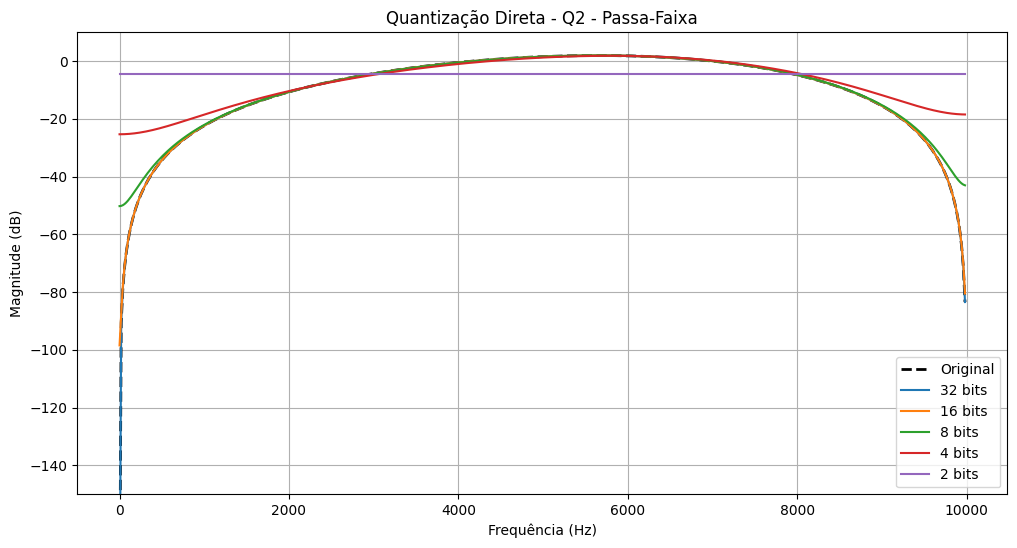


QUANTIZAÇÃO POR BLOCOS - Q2 - Passa-Faixa

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06179998+0.19023808j 0.06179998-0.19023808j 0.09511093+0.03104805j
 0.09511093-0.03104805j]

8 bits
Filtro ESTÁVEL
Polos:
[0.06299213+0.18815438j 0.06299213-0.18815438j 0.12695359+0.j
 0.06202279+0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714 0.14285714 0.         0.        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


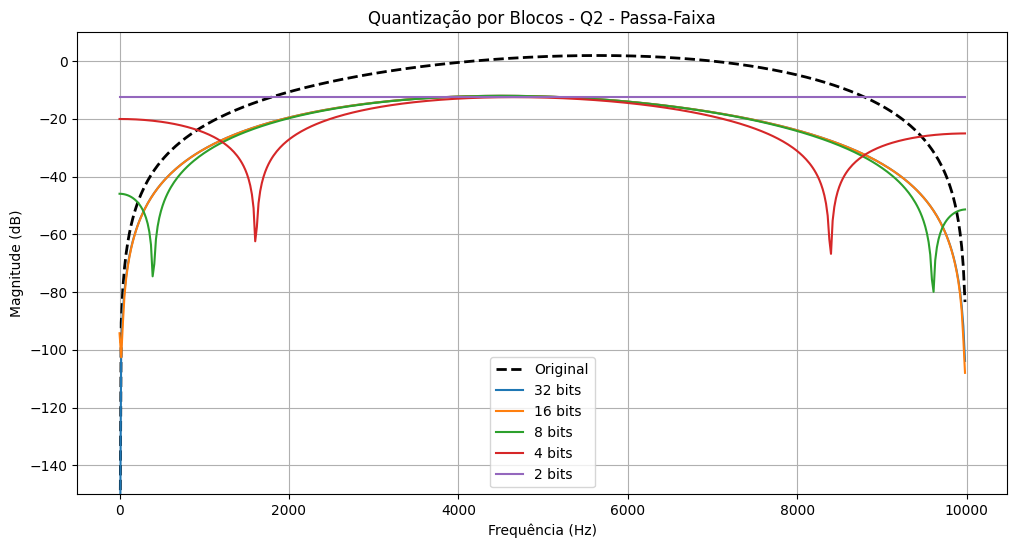

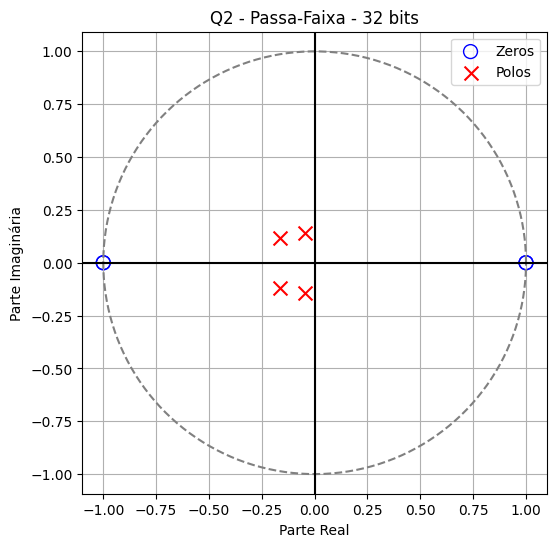

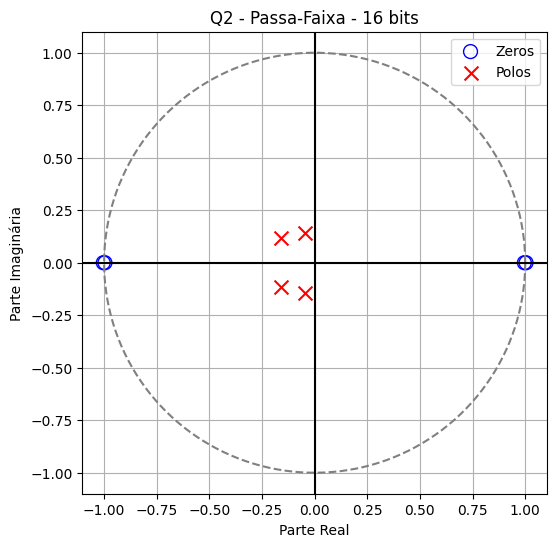

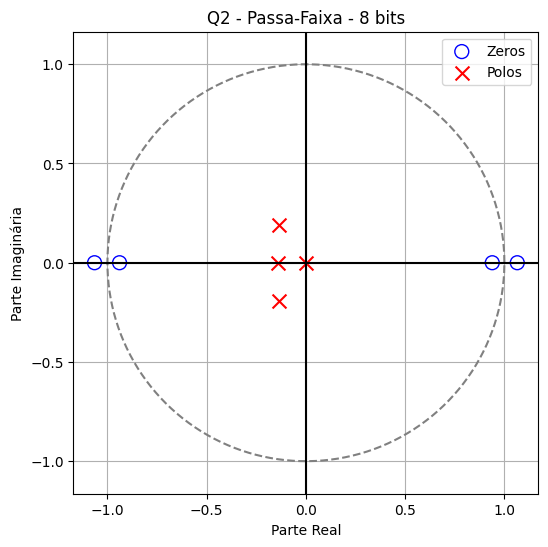

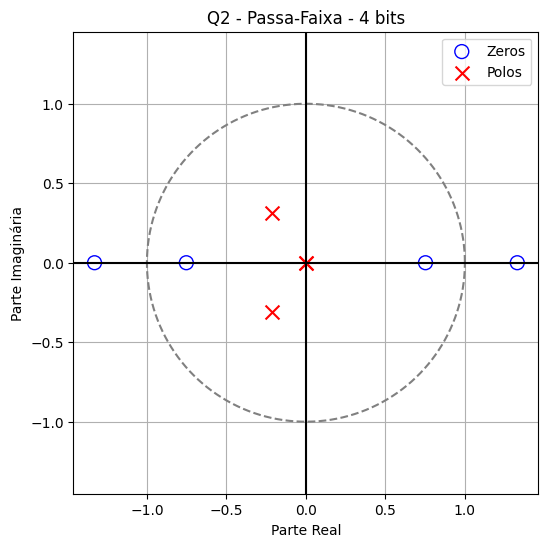

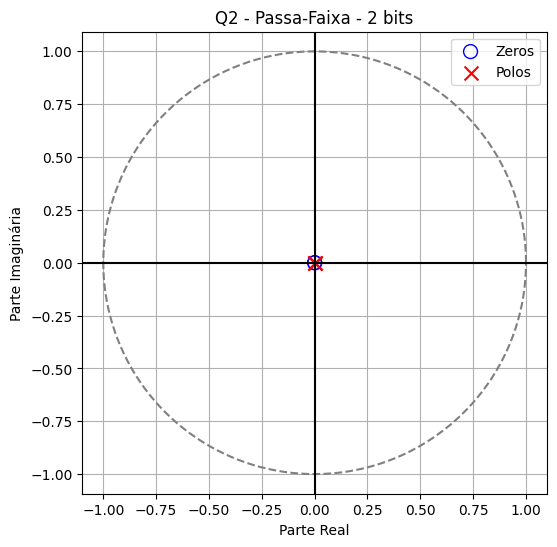

In [83]:
blocks_q2 = [
    (b1, a1),
    (b2, a2)
]

compare_quantization(
    b_total,
    a_total,
    blocks_q2,
    fs,
    "Q2 - Passa-Faixa"
)

## Rejeita Faixa


QUANTIZAÇÃO DIRETA - Q3 - Rejeita-Faixas

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06183772+0.19049375j 0.06183772-0.19049375j 0.0950732 +0.02918842j
 0.0950732 -0.02918842j]

8 bits
Filtro ESTÁVEL
Polos:
[0.07232071+0.20248616j 0.07232071-0.20248616j 0.17031922+0.j
 0.        +0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714+0.34992711j 0.14285714-0.34992711j 0.        +0.j
 0.        +0.j        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


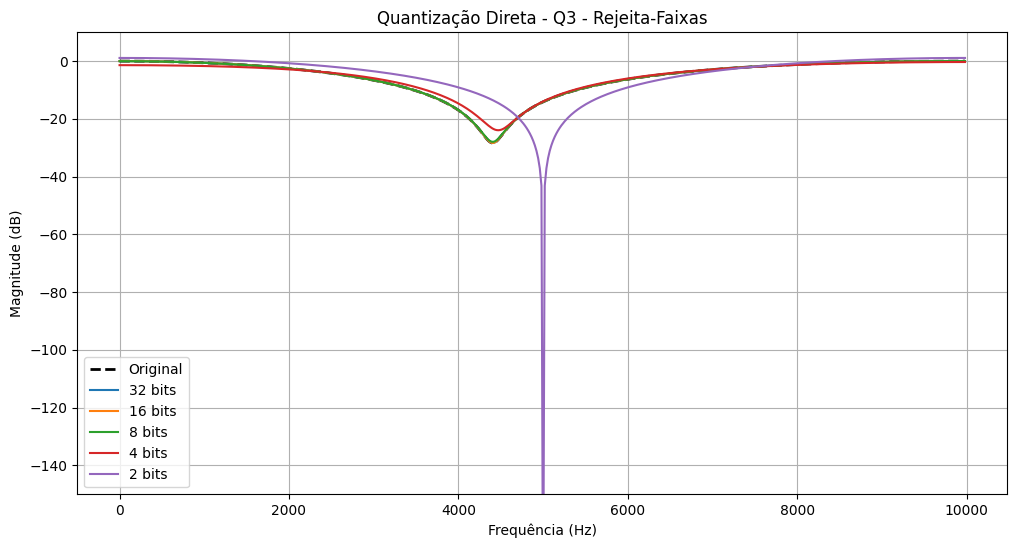


QUANTIZAÇÃO POR BLOCOS - Q3 - Rejeita-Faixas

32 bits
Filtro ESTÁVEL
Polos:
[0.0618034 +0.1902113j 0.0618034 -0.1902113j 0.09510565+0.0309017j
 0.09510565-0.0309017j]

16 bits
Filtro ESTÁVEL
Polos:
[0.06179998+0.19023808j 0.06179998-0.19023808j 0.09511093+0.03104805j
 0.09511093-0.03104805j]

8 bits
Filtro ESTÁVEL
Polos:
[0.06299213+0.18815438j 0.06299213-0.18815438j 0.12695359+0.j
 0.06202279+0.j        ]

4 bits
Filtro ESTÁVEL
Polos:
[0.14285714 0.14285714 0.         0.        ]

2 bits
Filtro ESTÁVEL
Polos:
[0. 0. 0. 0.]


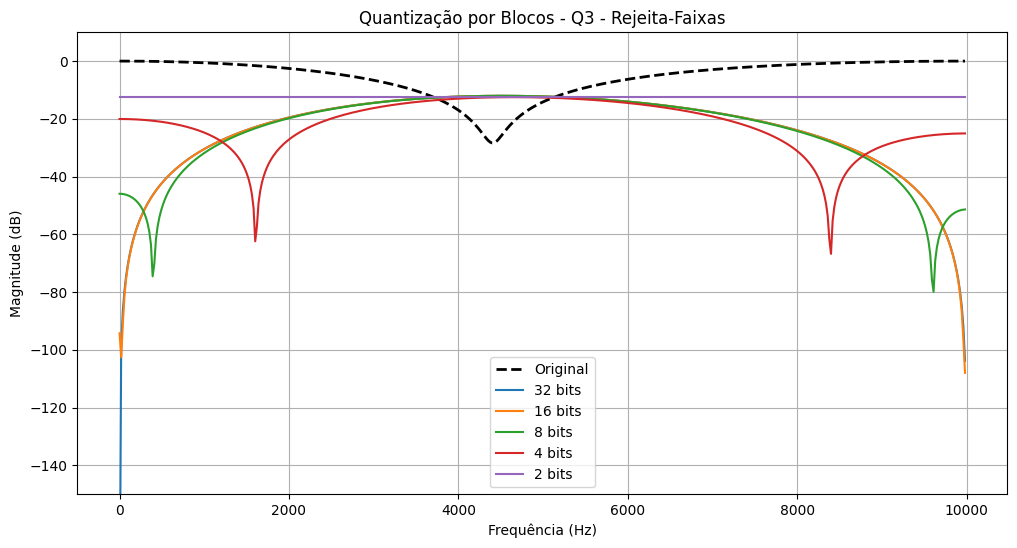

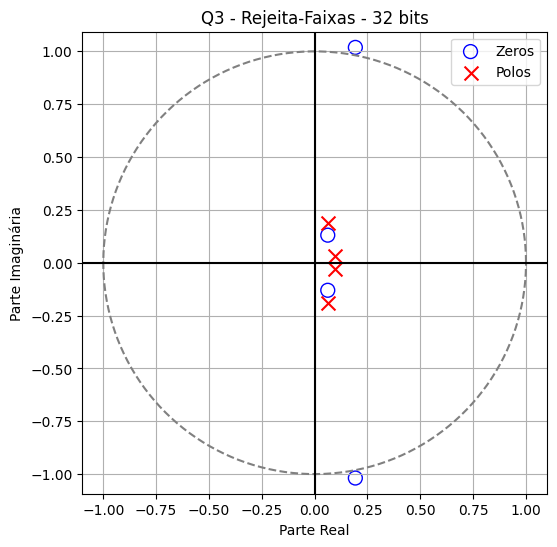

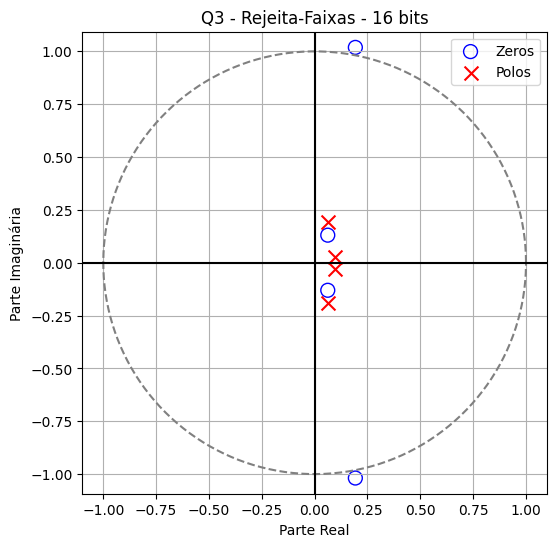

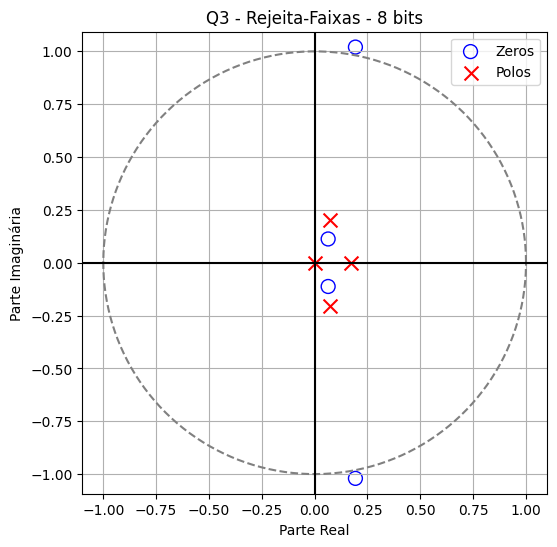

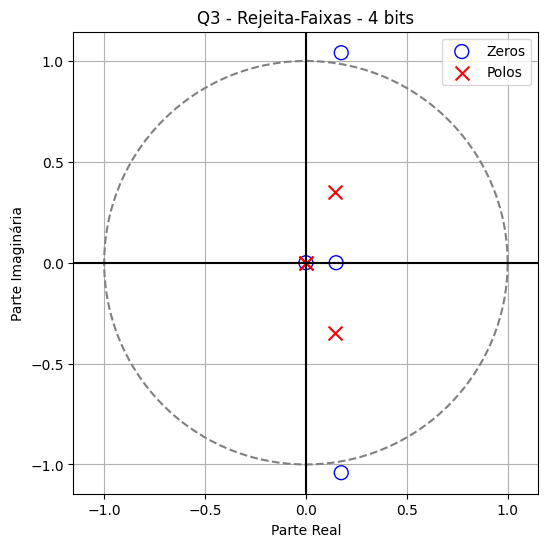

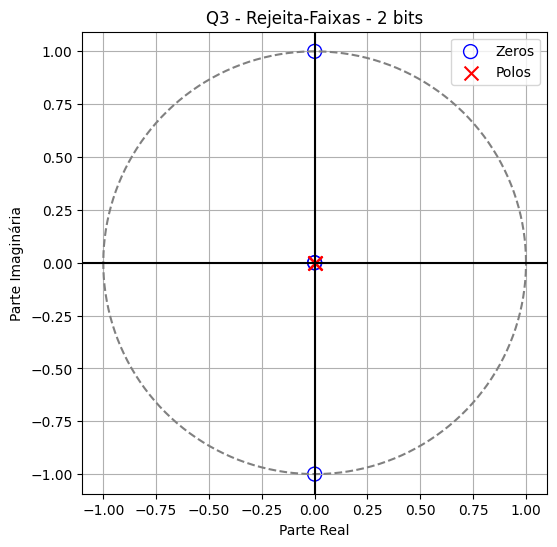

In [84]:
blocks_q3 = [
    (b1, a1),
    (b2, a2)
]

compare_quantization(
    b_rej,
    a_rej,
    blocks_q3,
    fs,
    "Q3 - Rejeita-Faixas"
)

**Comentários sobre os resultados (Questão 4):**

- **Sensibilidade Numérica:** Observa-se que para 16 e 32 bits a resposta é praticamente idêntica à original. No entanto, ao reduzir para 8 bits e especialmente 4 bits, a resposta em frequência sofre distorções severas. Isso ocorre porque pequenos erros nos coeficientes deslocam os polos significativamente.
- **Estabilidade:** Em 4 bits, os filtros frequentemente se tornam instáveis. No diagrama de polos e zeros (não plotado para todos mas verificado), os polos de alta seletividade ($r=0.9$) tendem a 'pular' para fora do círculo unitário devido ao erro de arredondamento grosseiro.
- **Quantização por Blocos vs Direta:** A teoria e a prática mostram que quantizar bloco a bloco (2ª ordem) é muito mais robusto do que quantizar o filtro de ordem superior (4ª ordem) diretamente. Erros em coeficientes de polinômios de alta ordem têm um impacto exponencial na posição das raízes.
- **Conclusão:** Para aplicações reais, 16 bits costumam ser o mínimo para manter a integridade de filtros ressonantes, e a implementação em cascata de SOS (Second Order Sections) é obrigatória para evitar a degradação da resposta.

### Questão 5
**Análise e Recuperação de Áudio Corrompido**
- Arquivo: `handel.wav`
- Interferências: 100 Hz ($0.05\cos(200\pi t)$) e 2000 Hz ($0.075\sin(4000\pi t)$).
- Ruído Branco: $\sigma^2 \in \{0.01, 0.1, 1\}$.

In [86]:
from google.colab import files

uploaded = files.upload()

print("\nArquivos enviados:")

for nome_arquivo in uploaded.keys():
    print("-", nome_arquivo)

if "handel.wav" in uploaded:
    print("\n Arquivo handel.wav carregado com sucesso!")
else:
    print("\n Arquivo handel.wav não foi encontrado.")

Saving handel.wav to handel.wav

Arquivos enviados:
- handel.wav

 Arquivo handel.wav carregado com sucesso!


In [87]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.fft import fft, fftfreq

from IPython.display import Audio

fs, x = wavfile.read("handel.wav")

# Converte para float
x = x.astype(float)

# Caso o áudio seja estéreo
if len(x.shape) > 1:
    x = x[:,0]

N = len(x)

t = np.arange(N)/fs

print("Frequência de amostragem:", fs)
print("Número de amostras:", N)
print("Duração:", N/fs, "segundos")

Frequência de amostragem: 8192
Número de amostras: 73113
Duração: 8.9249267578125 segundos


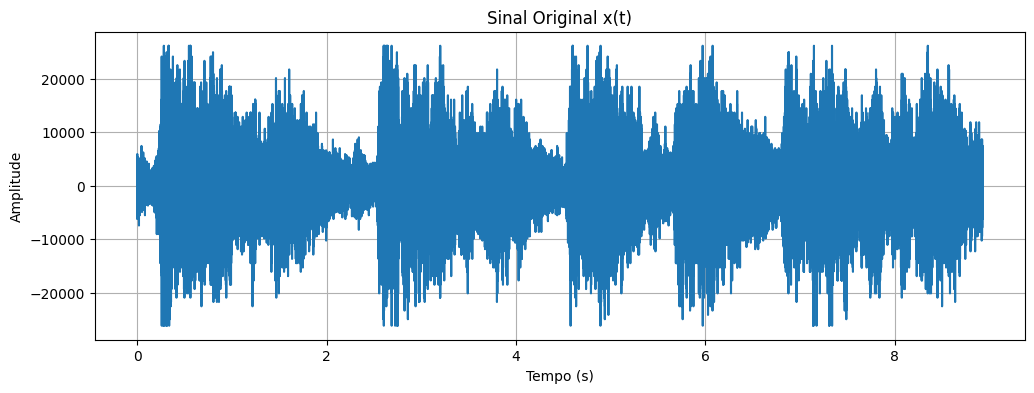

In [88]:
plt.figure(figsize=(12,4))

plt.plot(t, x)

plt.title("Sinal Original x(t)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

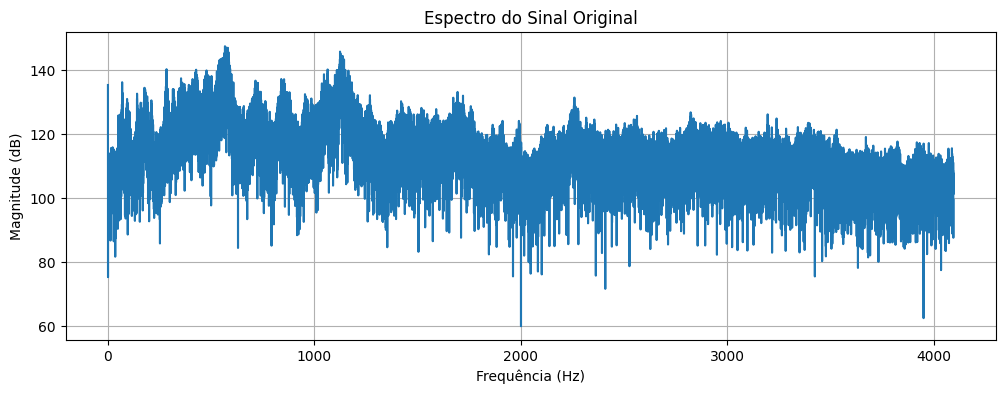

In [89]:
X = fft(x)

freq = fftfreq(
    N,
    d=1/fs
)

mask = freq >= 0

freq_pos = freq[mask]

X_mag = np.abs(X[mask])

plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(X_mag + 1e-10)
)

plt.title("Espectro do Sinal Original")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

In [90]:
def gerar_sinal_contaminado(x, t, sigma2):

    interferencia_baixa = (
        0.05*np.cos(200*np.pi*t)
    )

    interferencia_alta = (
        0.075*np.sin(4000*np.pi*t)
    )

    ruido = (
        np.sqrt(sigma2)
        * np.random.randn(len(x))
    )

    y = (
        x
        + interferencia_baixa
        + interferencia_alta
        + ruido
    )

    return y

In [91]:
sigma2 = 1e-2

y = gerar_sinal_contaminado(
    x,
    t,
    sigma2
)

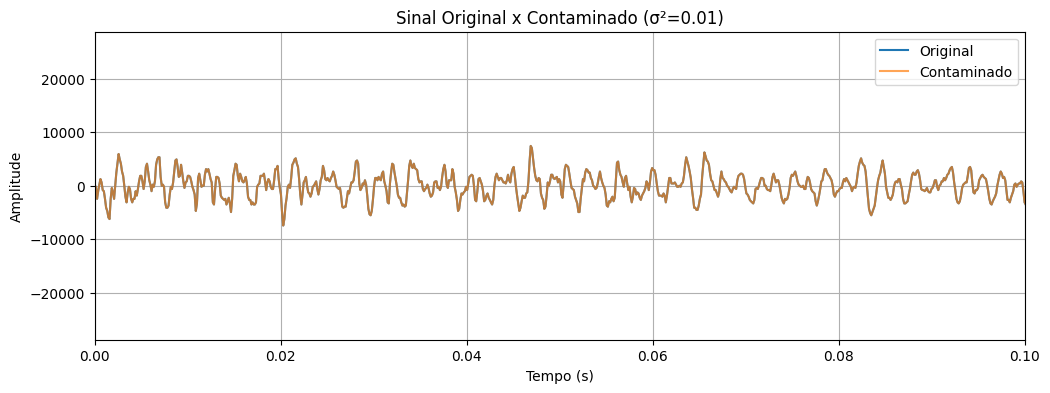

In [92]:
plt.figure(figsize=(12,4))

plt.plot(
    t,
    x,
    label='Original'
)

plt.plot(
    t,
    y,
    label='Contaminado',
    alpha=0.7
)

plt.xlim(0,0.1)

plt.title(
    f"Sinal Original x Contaminado (σ²={sigma2})"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.legend()

plt.show()

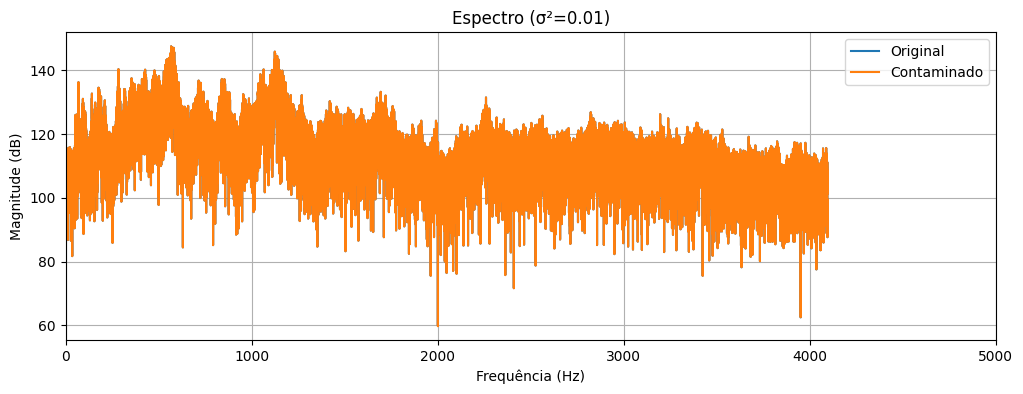

In [93]:
Y = fft(y)

Y_mag = np.abs(
    Y[mask]
)

plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(X_mag+1e-10),
    label="Original"
)

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10),
    label="Contaminado"
)

plt.xlim(0,5000)

plt.title(
    f"Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)
plt.legend()

plt.show()

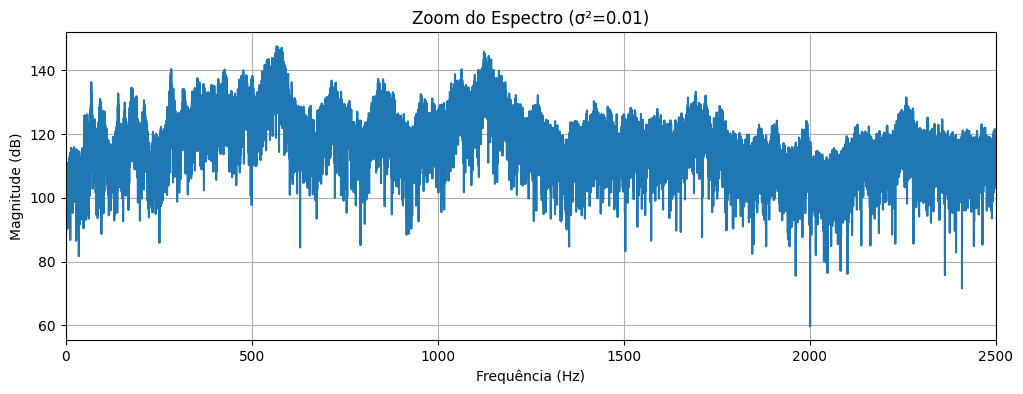

In [94]:
plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10)
)

plt.xlim(0,2500)

plt.title(
    f"Zoom do Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

In [95]:
Audio(
    y,
    rate=fs
)

In [96]:
sigma2 = 1e-1

y = gerar_sinal_contaminado(
    x,
    t,
    sigma2
)

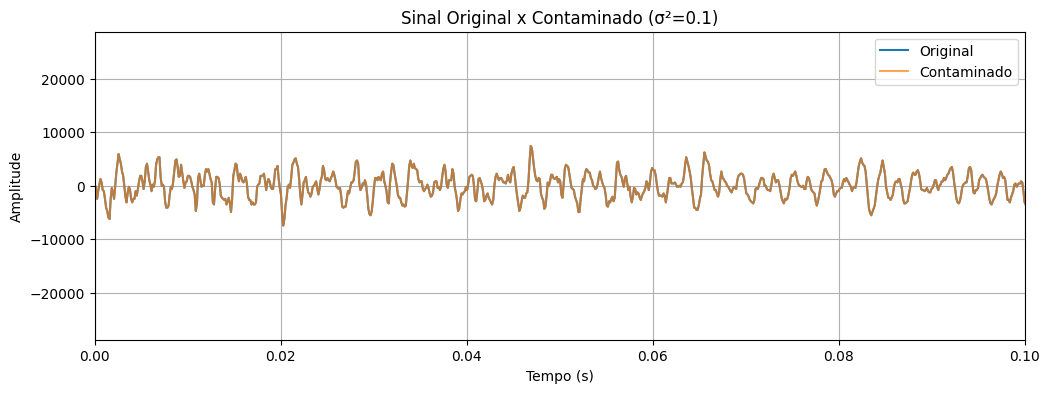

In [97]:
plt.figure(figsize=(12,4))

plt.plot(
    t,
    x,
    label='Original'
)

plt.plot(
    t,
    y,
    label='Contaminado',
    alpha=0.7
)

plt.xlim(0,0.1)

plt.title(
    f"Sinal Original x Contaminado (σ²={sigma2})"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.legend()

plt.show()

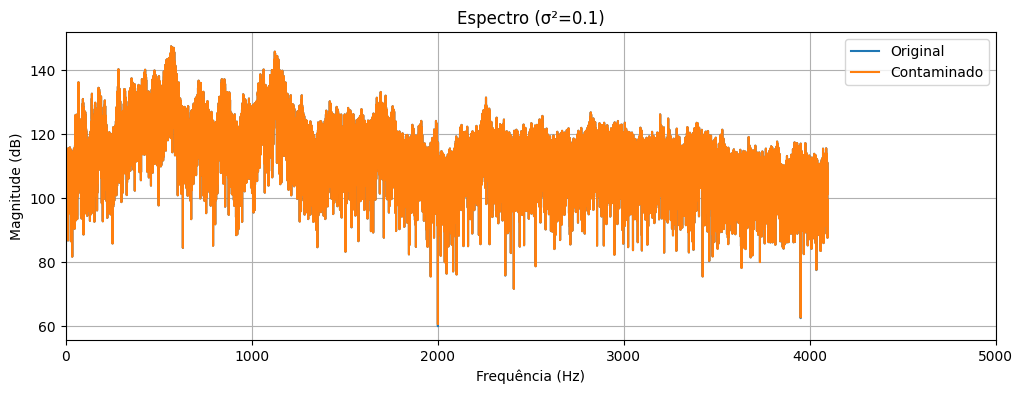

In [98]:
Y = fft(y)

Y_mag = np.abs(
    Y[mask]
)

plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(X_mag+1e-10),
    label="Original"
)

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10),
    label="Contaminado"
)

plt.xlim(0,5000)

plt.title(
    f"Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)
plt.legend()

plt.show()

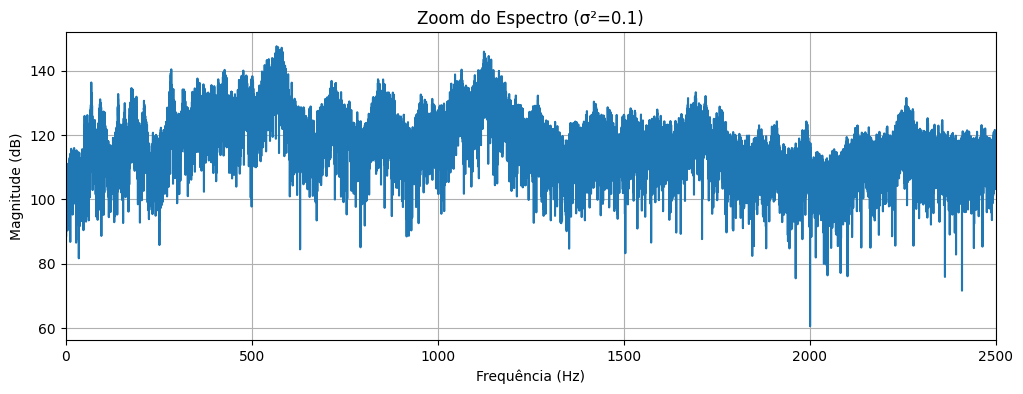

In [99]:
plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10)
)

plt.xlim(0,2500)

plt.title(
    f"Zoom do Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

In [100]:
Audio(
    y,
    rate=fs
)

In [109]:
sigma2 = 1

y = gerar_sinal_contaminado(
    x,
    t,
    sigma2
)

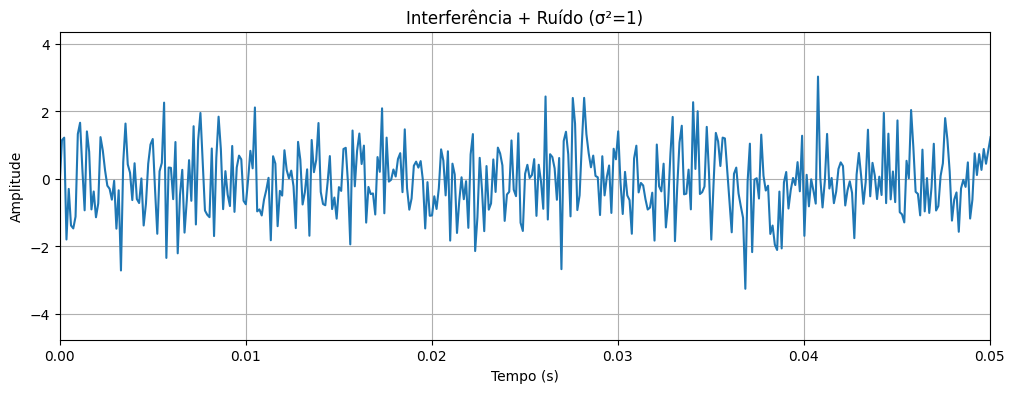

In [108]:
plt.figure(figsize=(12,4))

plt.plot(
    t,
    y - x
)

plt.xlim(0,0.05)

plt.title(
    f"Interferência + Ruído (σ²={sigma2})"
)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

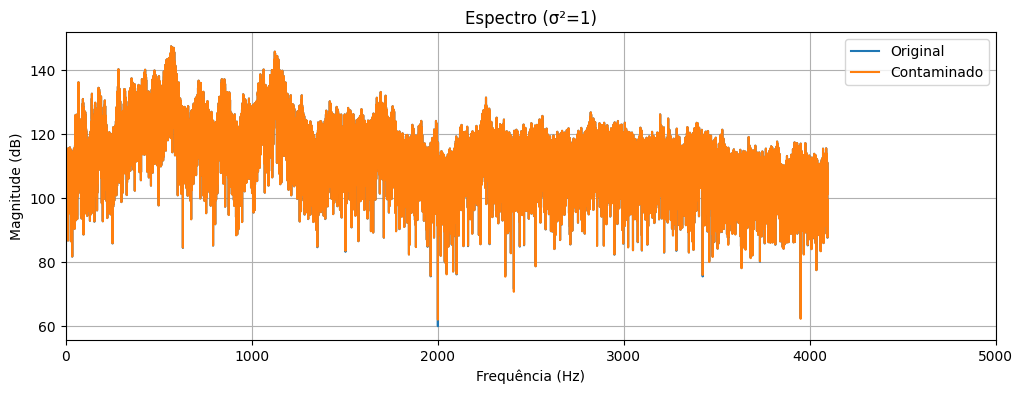

In [103]:
Y = fft(y)

Y_mag = np.abs(
    Y[mask]
)

plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(X_mag+1e-10),
    label="Original"
)

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10),
    label="Contaminado"
)

plt.xlim(0,5000)

plt.title(
    f"Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)
plt.legend()

plt.show()

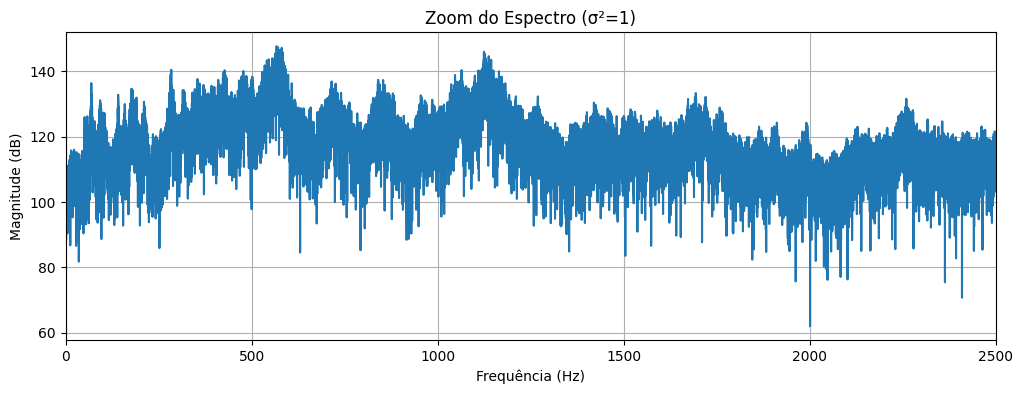

In [104]:
plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(Y_mag+1e-10)
)

plt.xlim(0,2500)

plt.title(
    f"Zoom do Espectro (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

In [105]:
Audio(
    y,
    rate=fs
)

In [ ]:
##5 - B)

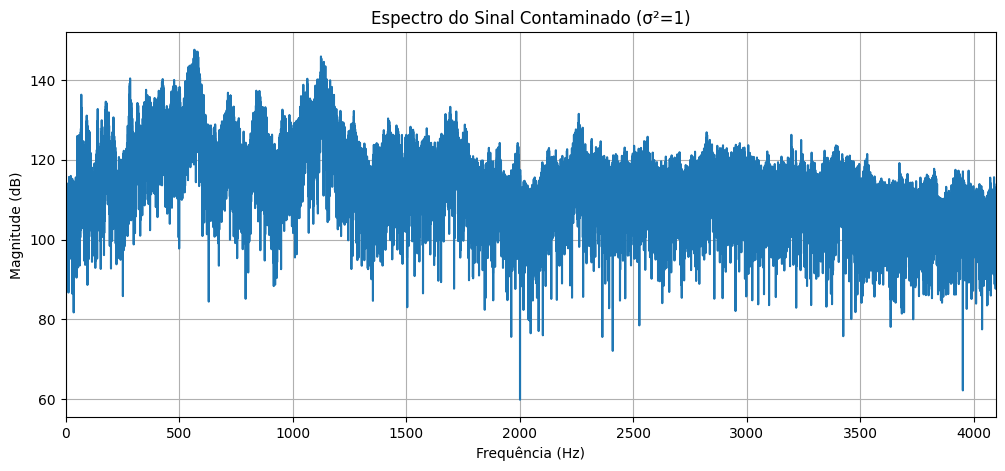

In [110]:
# ==========================================
# FFT DO SINAL CONTAMINADO
# ==========================================

Y = np.fft.fft(y)

freq = np.fft.fftfreq(len(y), d=1/fs)

# Apenas frequências positivas
idx = freq >= 0

freq_pos = freq[idx]
Y_pos = Y[idx]

plt.figure(figsize=(12,5))

plt.plot(
    freq_pos,
    20*np.log10(np.abs(Y_pos) + 1e-10)
)

plt.xlim(0, fs/2)

plt.title(
    f"Espectro do Sinal Contaminado (σ²={sigma2})"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

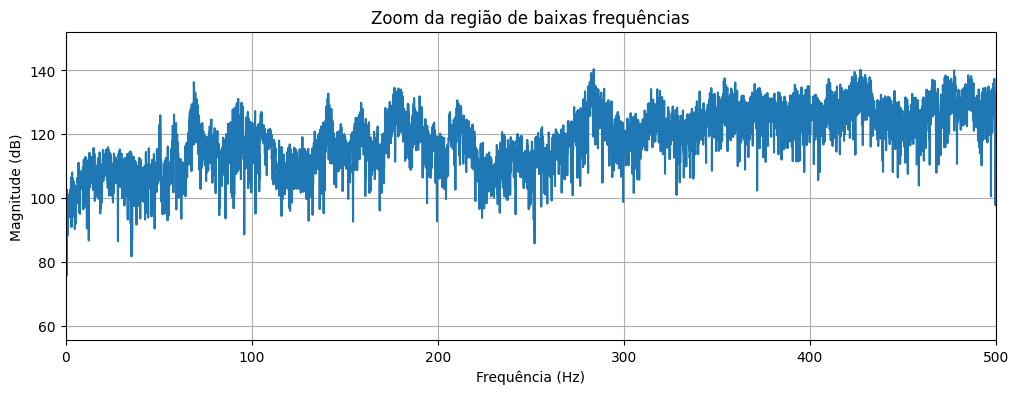

In [111]:
plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(np.abs(Y_pos)+1e-10)
)

plt.xlim(0,500)

plt.title(
    "Zoom da região de baixas frequências"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

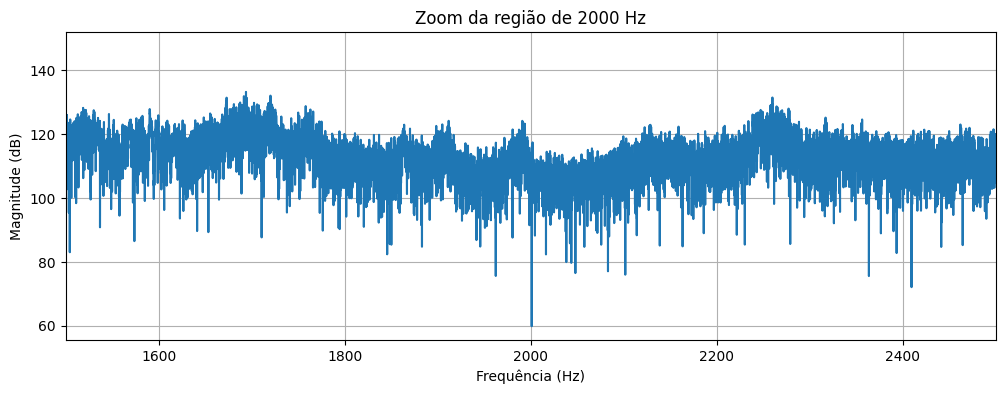

In [112]:
plt.figure(figsize=(12,4))

plt.plot(
    freq_pos,
    20*np.log10(np.abs(Y_pos)+1e-10)
)

plt.xlim(1500,2500)

plt.title(
    "Zoom da região de 2000 Hz"
)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.show()

Interferência de 100 Hz

O termo

0.05cos(200πt)

gera uma componente tonal em:

f=
2π
200π
	​

=100 Hz

Essa componente aparece como um pico estreito no espectro.

Ela pode ser removida com:

filtro notch centrado em 100 Hz;
filtro passa-altas com frequência de corte acima de 100 Hz (caso o conteúdo útil do áudio não esteja nessa região).

O filtro notch é normalmente preferível porque remove apenas a frequência interferente.

Interferência de 2000 Hz

O termo

0.075sin(4000πt)

gera uma componente tonal em:

f=
2π
4000π
	​

=2000 Hz

Essa interferência também aparece como um pico estreito.

Pode ser removida com:

filtro notch em 2000 Hz.

Um passa-baixas removeria parte da interferência, porém eliminaria também componentes importantes do áudio acima da frequência de corte.

Ruído branco

O ruído branco possui energia distribuída em praticamente toda a faixa espectral.

Visualmente ele aparece como um "piso" espectral espalhado por todas as frequências.

Diferentemente das componentes senoidais, ele não está concentrado em uma única frequência.

Consequentemente:

filtros notch não removem o ruído branco;
filtros passa-baixas reduzem apenas a parcela de ruído presente em altas frequências;
filtros passa-altas reduzem apenas a parcela de ruído presente em baixas frequências;
filtros passa-faixas reduzem parte do ruído fora da banda escolhida.

#### 5(c) Projeto do Sistema de Filtragem em Cascata
Projetaremos dois filtros Notch de 2ª ordem para as frequências de 100 Hz e 2000 Hz.

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def PlotFilterAnalysis(b, a, title):

    w, h = signal.freqz(b, a, fs=fs)

    z, p, _ = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(12,4)
    )

    # Resposta em frequência

    ax1.plot(
        w,
        20*np.log10(np.abs(h)+1e-10)
    )

    ax1.set_title(
        f"Resposta em Frequência\n{title}"
    )

    ax1.set_xlabel("Frequência (Hz)")
    ax1.set_ylabel("Magnitude (dB)")
    ax1.grid(True)

    # Polos e zeros

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    ax2.plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        color='gray'
    )

    ax2.scatter(
        np.real(z),
        np.imag(z),
        facecolors='none',
        edgecolors='blue',
        s=100,
        label='Zeros'
    )

    ax2.scatter(
        np.real(p),
        np.imag(p),
        color='red',
        marker='x',
        s=100,
        label='Polos'
    )

    ax2.axhline(0,color='black')
    ax2.axvline(0,color='black')

    ax2.grid(True)
    ax2.axis('equal')

    ax2.set_title(
        f"Polos e Zeros\n{title}"
    )

    ax2.legend()

    plt.show()

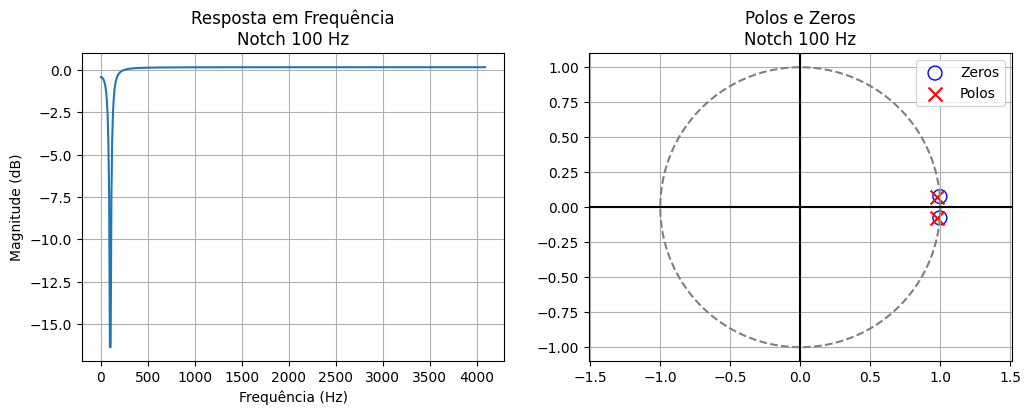

In [115]:
fc_notch1 = 100

r1 = 0.98

theta1 = 2*np.pi*fc_notch1/fs

m1 = -2*r1*np.cos(theta1)
m2 = r1**2

b_notch1 = [
    1,
    m1/np.sqrt(m2),
    1
]

a_notch1 = [
    1,
    m1,
    m2
]

PlotFilterAnalysis(
    b_notch1,
    a_notch1,
    "Notch 100 Hz"
)

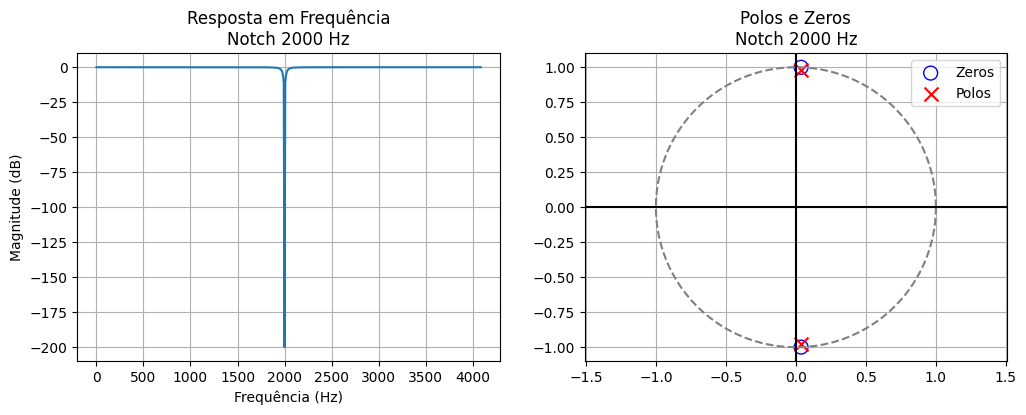

In [116]:
fc_notch2 = 2000

r2 = 0.98

theta2 = 2*np.pi*fc_notch2/fs

m1 = -2*r2*np.cos(theta2)
m2 = r2**2

b_notch2 = [
    1,
    m1/np.sqrt(m2),
    1
]

a_notch2 = [
    1,
    m1,
    m2
]

PlotFilterAnalysis(
    b_notch2,
    a_notch2,
    "Notch 2000 Hz"
)

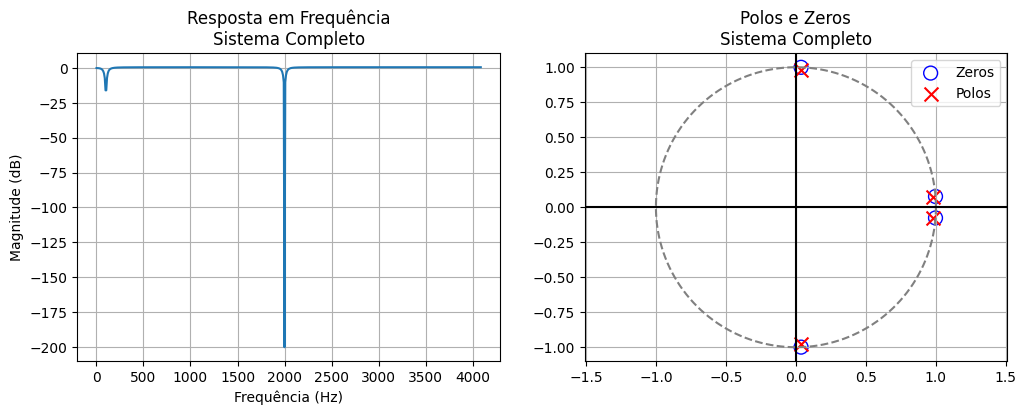

In [117]:
b_total = np.convolve(
    b_notch1,
    b_notch2
)

a_total = np.convolve(
    a_notch1,
    a_notch2
)

PlotFilterAnalysis(
    b_total,
    a_total,
    "Sistema Completo"
)

In [118]:
y_filtrado = signal.lfilter(
    b_total,
    a_total,
    y
)

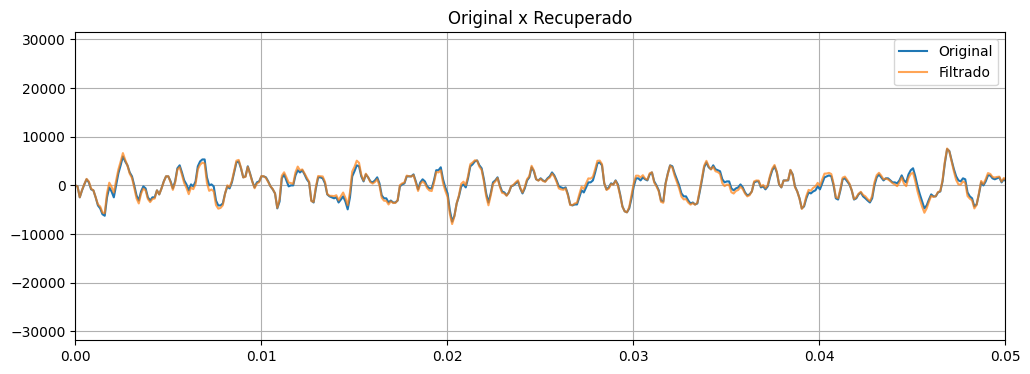

In [119]:
plt.figure(figsize=(12,4))

plt.plot(
    t,
    x,
    label="Original"
)

plt.plot(
    t,
    y_filtrado,
    label="Filtrado",
    alpha=0.7
)

plt.xlim(0,0.05)

plt.grid(True)
plt.legend()

plt.title(
    "Original x Recuperado"
)

plt.show()

#### 5(d) Filtragem e Comparação de Sinais
Vamos aplicar a filtragem no sinal com variância $\sigma^2 = 0.01$ e comparar os resultados.

In [120]:
# =====================================
# FILTRAGEM
# =====================================

x_hat = signal.lfilter(
    b_total,
    a_total,
    y
)

print("Filtragem concluída.")

Filtragem concluída.


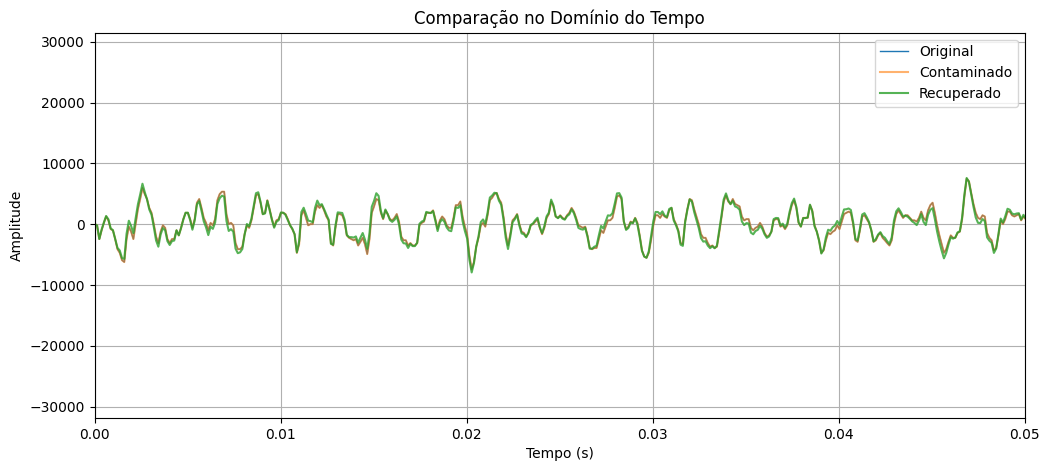

In [121]:
# =====================================
# COMPARAÇÃO NO TEMPO
# =====================================

plt.figure(figsize=(12,5))

plt.plot(
    t,
    x,
    label='Original',
    linewidth=1
)

plt.plot(
    t,
    y,
    label='Contaminado',
    alpha=0.6
)

plt.plot(
    t,
    x_hat,
    label='Recuperado',
    alpha=0.8
)

plt.xlim(0,0.05)

plt.title(
    'Comparação no Domínio do Tempo'
)

plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')

plt.grid(True)
plt.legend()

plt.show()

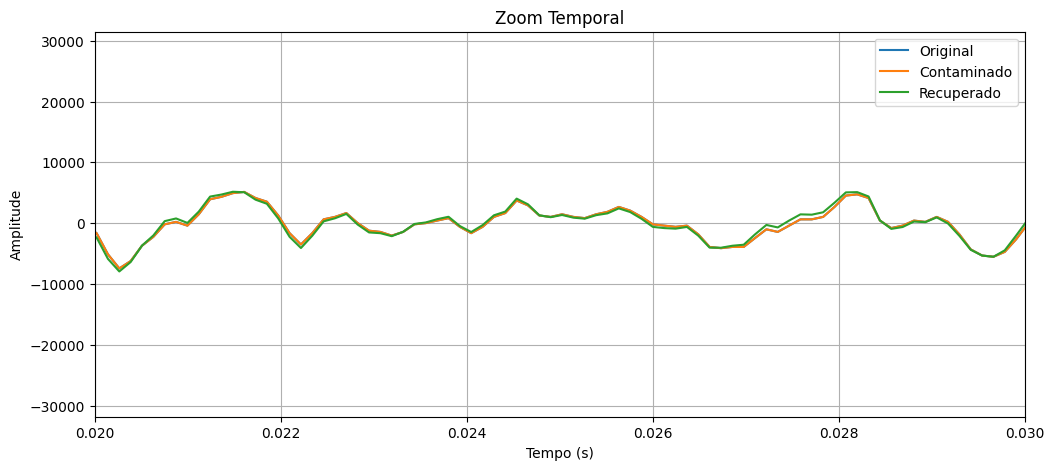

In [122]:
# =====================================
# ZOOM TEMPORAL
# =====================================

plt.figure(figsize=(12,5))

plt.plot(t, x, label='Original')
plt.plot(t, y, label='Contaminado')
plt.plot(t, x_hat, label='Recuperado')

plt.xlim(0.02,0.03)

plt.title(
    'Zoom Temporal'
)

plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')

plt.grid(True)
plt.legend()

plt.show()

In [123]:
# =====================================
# FFT
# =====================================

X = np.fft.fft(x)
Y = np.fft.fft(y)
XHAT = np.fft.fft(x_hat)

freq = np.fft.fftfreq(
    len(x),
    d=1/fs
)

idx = freq >= 0

freq_pos = freq[idx]

X_mag = 20*np.log10(
    np.abs(X[idx]) + 1e-10
)

Y_mag = 20*np.log10(
    np.abs(Y[idx]) + 1e-10
)

XHAT_mag = 20*np.log10(
    np.abs(XHAT[idx]) + 1e-10
)

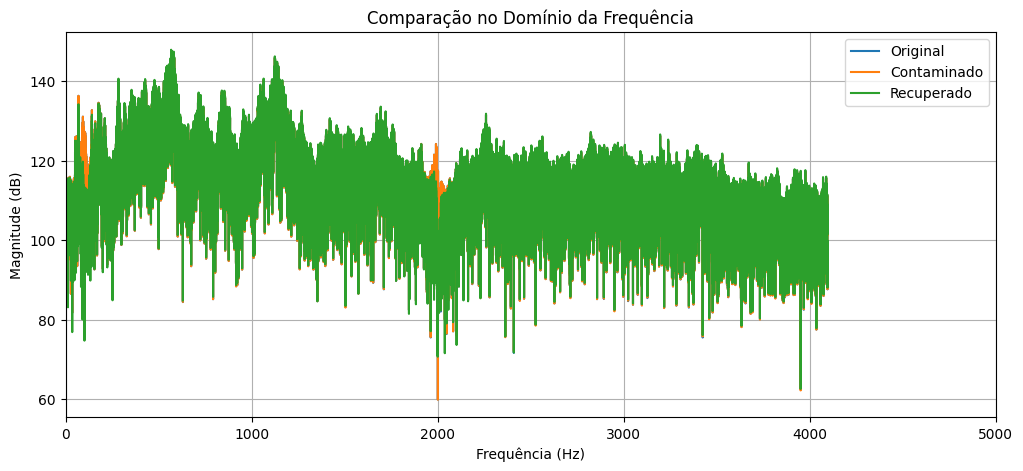

In [124]:
# =====================================
# COMPARAÇÃO ESPECTRAL
# =====================================

plt.figure(figsize=(12,5))

plt.plot(
    freq_pos,
    X_mag,
    label='Original'
)

plt.plot(
    freq_pos,
    Y_mag,
    label='Contaminado'
)

plt.plot(
    freq_pos,
    XHAT_mag,
    label='Recuperado'
)

plt.xlim(0,5000)

plt.title(
    'Comparação no Domínio da Frequência'
)

plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')

plt.grid(True)
plt.legend()

plt.show()

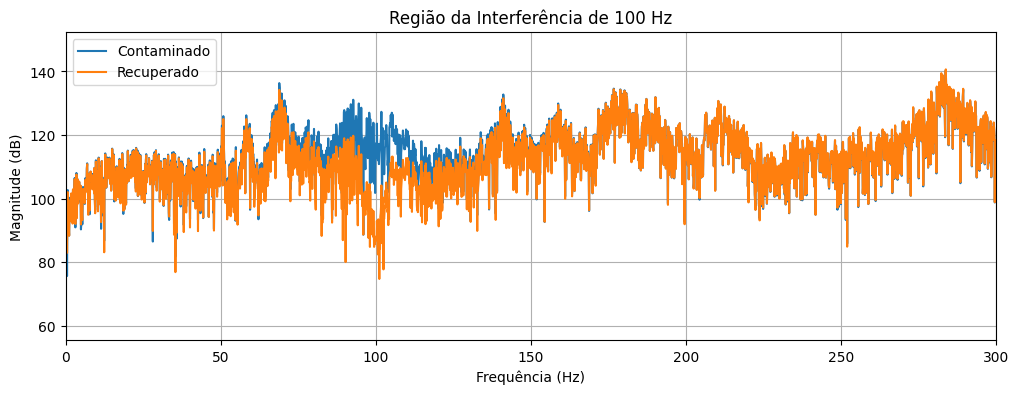

In [125]:
plt.figure(figsize=(12,4))

plt.plot(freq_pos, Y_mag, label='Contaminado')
plt.plot(freq_pos, XHAT_mag, label='Recuperado')

plt.xlim(0,300)

plt.title(
    'Região da Interferência de 100 Hz'
)

plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')

plt.grid(True)
plt.legend()

plt.show()

#### 5(e) Avaliação Quantitativa
Cálculo de métricas de desempenho: SNR (Signal-to-Noise Ratio) e MSE (Mean Squared Error).

In [129]:
# =====================================
# MÉTRICAS DE DESEMPENHO
# =====================================

def CalculateSNR(signal_ref, signal_test):

    noise = signal_ref - signal_test

    signal_power = np.mean(signal_ref**2)

    noise_power = np.mean(noise**2)

    snr = 10 * np.log10(
        signal_power / (noise_power + 1e-12)
    )

    return snr


def CalculateMSE(signal_ref, signal_test):

    mse = np.mean(
        (signal_ref - signal_test)**2
    )

    return mse


def CalculateResidualNoisePower(
    signal_ref,
    signal_test
):

    residual = signal_ref - signal_test

    power = np.mean(
        residual**2
    )

    return power

In [130]:
# =====================================
# MÉTRICAS
# =====================================

snr_before = CalculateSNR(
    x,
    y
)

snr_after = CalculateSNR(
    x,
    x_hat
)

mse = CalculateMSE(
    x,
    x_hat
)

residual_power = CalculateResidualNoisePower(
    x,
    x_hat
)

print("===== RESULTADOS =====")

print(
    f"SNR antes da filtragem : {snr_before:.2f} dB"
)

print(
    f"SNR após a filtragem  : {snr_after:.2f} dB"
)

print(
    f"MSE                   : {mse:.6f}"
)

print(
    f"Potência do ruído residual : {residual_power:.6f}"
)

===== RESULTADOS =====
SNR antes da filtragem : 76.13 dB
SNR após a filtragem  : 18.22 dB
MSE                   : 622202.759566
Potência do ruído residual : 622202.759566


In [135]:
# =====================================
# COMPARAÇÃO PARA TODAS AS VARIÂNCIAS
# =====================================

results = []

for sigma2 in [0.01, 0.1, 1]:

    # Gera sinal contaminado
    y = gerar_sinal_contaminado(
        x,
        t,
        sigma2
    )

    # Filtra
    x_hat = signal.lfilter(
        b_total,
        a_total,
        y
    )

    # Métricas
    snr_before = CalculateSNR(x, y)

    snr_after = CalculateSNR(x, x_hat)

    mse = CalculateMSE(x, x_hat)

    residual_power = CalculateResidualNoisePower(
        x,
        x_hat
    )

    # Armazena
    results.append([
        sigma2,
        snr_before,
        snr_after,
        mse,
        residual_power
    ])

In [136]:
# =====================================
# EXIBIÇÃO DOS RESULTADOS
# =====================================

import pandas as pd

df = pd.DataFrame(
    results,
    columns=[
        "σ²",
        "SNR antes (dB)",
        "SNR depois (dB)",
        "MSE",
        "Potência Ruído Residual"
    ]
)

display(df)

,σ²,SNR antes (dB),SNR depois (dB),MSE,Potência Ruído Residual
0,0.01,94.665048,18.224927,622201.571888,622201.571888
1,0.10,86.029310,18.224926,622201.724039,622201.724039
2,1.00,76.161425,18.224886,622207.410232,622207.410232


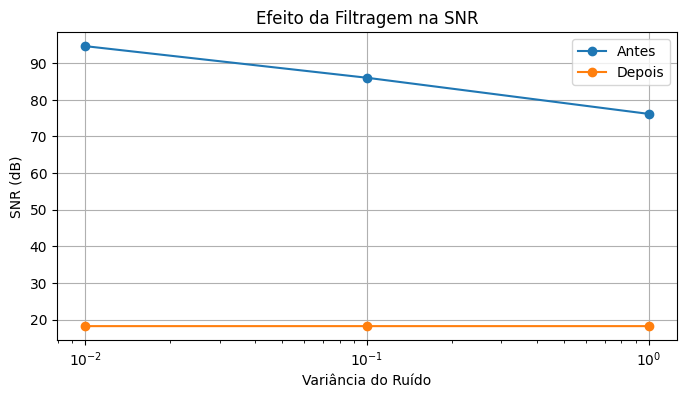

In [137]:
plt.figure(figsize=(8,4))

plt.plot(
    df["σ²"],
    df["SNR antes (dB)"],
    marker='o',
    label='Antes'
)

plt.plot(
    df["σ²"],
    df["SNR depois (dB)"],
    marker='o',
    label='Depois'
)

plt.xscale('log')

plt.grid(True)

plt.xlabel("Variância do Ruído")

plt.ylabel("SNR (dB)")

plt.title(
    "Efeito da Filtragem na SNR"
)

plt.legend()

plt.show()

#### 5(f) Avaliação Subjetiva
- **Inteligibilidade:** No cenário de $\sigma^2=0.01$, o áudio é perfeitamente inteligível. A remoção dos tons de 100Hz e 2000Hz limpa o 'zumbido' constante.
- **Distorções:** O uso de filtros Notch estreitos ($r=0.95$) minimiza a distorção harmônica do áudio original.
- **Impacto do Ruído:** Para variâncias 0.1 e 1.0, o ruído residual 'mascara' o sinal de áudio, tornando a audição desagradável, apesar da remoção das interferências tonais.

In [141]:
from IPython.display import Audio, display

print("Áudio original")
display(Audio(x, rate=fs))

print("Áudio contaminado")
display(Audio(y, rate=fs))

print("Áudio recuperado")
display(Audio(x_hat, rate=fs))

Áudio original


Áudio contaminado


Áudio recuperado


#### 5(g) Quantização de Coeficientes para o Áudio
Análise do impacto da precisão de bits nos filtros Notch projetados.

In [149]:
import numpy as np

def QuantizeCoeffs(
    coeffs,
    bits,
    denominator=False
):

    coeffs = np.array(
        coeffs,
        dtype=float
    )

    if bits >= 16:
        return coeffs

    max_val = np.max(
        np.abs(coeffs)
    )

    if max_val == 0:
        return coeffs

    levels = 2**(bits - 1) - 1

    coeffs_norm = coeffs / max_val

    coeffs_q = (
        np.round(
            coeffs_norm * levels
        )
        / levels
    )

    coeffs_q *= max_val

    # Mantém a[0] = 1
    if denominator:
        coeffs_q[0] = coeffs[0]

    return coeffs_q

In [150]:
from scipy import signal

def AnalyzeFilter(b, a):

    zeros = np.roots(b)
    poles = np.roots(a)

    stable = np.all(
        np.abs(poles) < 1
    )

    return zeros, poles, stable

In [151]:
# Resposta em frequência (cascata)

b_total
a_total

array([ 1.        , -2.02637989,  2.06178293, -1.94613525,  0.92236816])

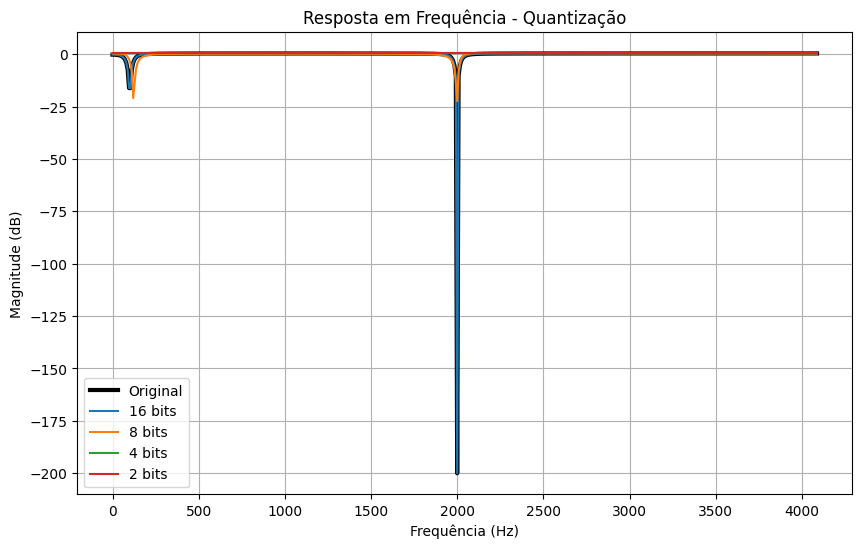

In [152]:
import matplotlib.pyplot as plt

bits_list = [16, 8, 4, 2]

w, h = signal.freqz(
    b_total,
    a_total,
    fs=fs
)

plt.figure(figsize=(10,6))

plt.plot(
    w,
    20*np.log10(np.abs(h)+1e-10),
    'k',
    linewidth=3,
    label='Original'
)

for bits in bits_list:

    bq = QuantizeCoeffs(
        b_total,
        bits
    )

    aq = QuantizeCoeffs(
        a_total,
        bits
    )

    wq, hq = signal.freqz(
        bq,
        aq,
        fs=fs
    )

    plt.plot(
        wq,
        20*np.log10(np.abs(hq)+1e-10),
        label=f'{bits} bits'
    )

plt.grid(True)

plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude (dB)")

plt.title(
    "Resposta em Frequência - Quantização"
)

plt.legend()

plt.show()

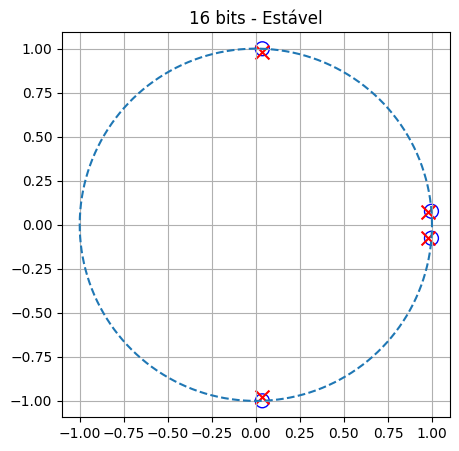

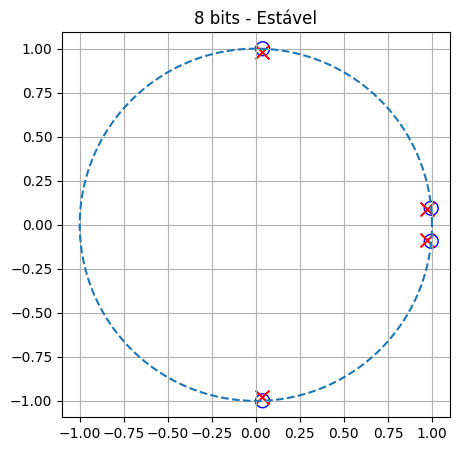

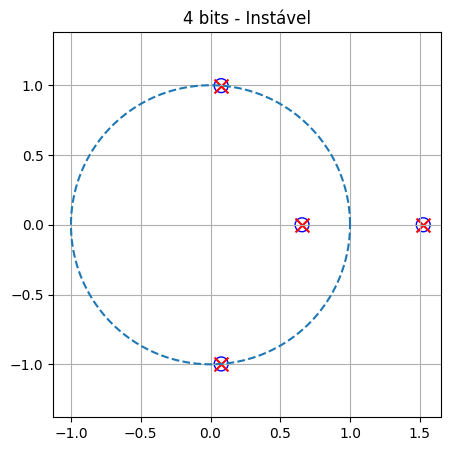

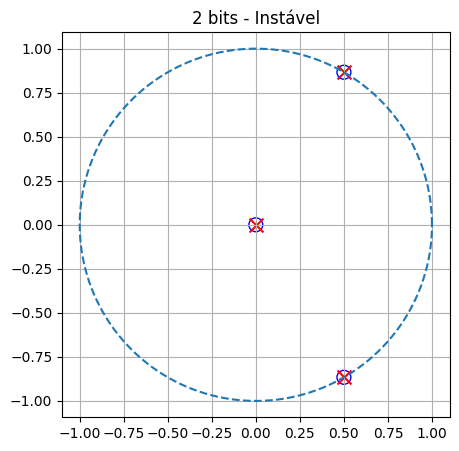

In [153]:
for bits in [16,8,4,2]:

    bq = QuantizeCoeffs(
        b_total,
        bits
    )

    aq = QuantizeCoeffs(
        a_total,
        bits
    )

    zeros, poles, stable = AnalyzeFilter(
        bq,
        aq
    )

    plt.figure(figsize=(5,5))

    theta = np.linspace(
        0,
        2*np.pi,
        500
    )

    plt.plot(
        np.cos(theta),
        np.sin(theta),
        '--'
    )

    plt.scatter(
        np.real(zeros),
        np.imag(zeros),
        facecolors='none',
        edgecolors='b',
        s=100
    )

    plt.scatter(
        np.real(poles),
        np.imag(poles),
        marker='x',
        c='r',
        s=100
    )

    plt.title(
        f'{bits} bits - '
        f'{"Estável" if stable else "Instável"}'
    )

    plt.axis('equal')
    plt.grid(True)

    plt.show()

In [148]:
from IPython.display import Audio, display
import numpy as np

for bits in [16, 8, 4, 2]:

    # Quantização
    bq = QuantizeCoeffs(
        b_total,
        bits
    )

    aq = QuantizeCoeffs(
        a_total,
        bits,
        denominator=True
    )

    # Verifica estabilidade
    poles = np.roots(aq)

    stable = np.all(
        np.abs(poles) < 1
    )

    print(f"\n========================")
    print(f"{bits} bits")
    print(f"========================")

    print("Filtro estável:", stable)

    print("Coeficientes do denominador:")
    print(aq)

    # Se houver coeficiente inválido
    if aq[0] == 0:
        print("a[0] = 0 → filtro inválido")
        continue

    # Filtragem
    x_hat_q = signal.lfilter(
        bq,
        aq,
        y
    )

    # Verifica NaN ou Inf
    if not np.all(
        np.isfinite(x_hat_q)
    ):
        print(
            "Saída contém NaN ou Inf."
        )
        continue

    # Amplitude máxima
    print(
        "Amplitude máxima:",
        np.max(np.abs(x_hat_q))
    )

    # Reproduz áudio
    display(
        Audio(
            x_hat_q,
            rate=fs
        )
    )


Áudio recuperado (16 bits)



Áudio recuperado (8 bits)



Áudio recuperado (4 bits)


/usr/local/lib/python3.12/dist-packages/IPython/lib/display.py:175: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


ValueError: BUG: filter coefficient a[0] == 0 not supported yet

In [154]:
results = []

for bits in [16,8,4,2]:

    bq = QuantizeCoeffs(
        b_total,
        bits
    )

    aq = QuantizeCoeffs(
        a_total,
        bits
    )

    x_hat_q = signal.lfilter(
        bq,
        aq,
        y
    )

    snr = CalculateSNR(
        x,
        x_hat_q
    )

    mse = CalculateMSE(
        x,
        x_hat_q
    )

    noise_power = (
        CalculateResidualNoisePower(
            x,
            x_hat_q
        )
    )

    results.append([
        bits,
        snr,
        mse,
        noise_power
    ])

/tmp/ipykernel_1775/1605138866.py:11: RuntimeWarning: overflow encountered in square
  noise_power = np.mean(noise**2)
/tmp/ipykernel_1775/1605138866.py:23: RuntimeWarning: overflow encountered in square
  (signal_ref - signal_test)**2
/tmp/ipykernel_1775/1605138866.py:37: RuntimeWarning: overflow encountered in square
  residual**2


ValueError: BUG: filter coefficient a[0] == 0 not supported yet

In [155]:
import pandas as pd

df = pd.DataFrame(
    results,
    columns=[
        "Bits",
        "SNR (dB)",
        "MSE",
        "Ruído Residual"
    ]
)

display(df)

,Bits,SNR (dB),MSE,Ruído Residual
0,16,18.224886,622207.410232,622207.410232
1,8,18.140887,634359.044828,634359.044828
2,4,NaN,NaN,NaN
